In [1]:
import sys
import subprocess

# Install required packages using subprocess for consistency across all environments (Colab, local, any Python environment)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "praat-parselmouth", "--break-system-packages"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "textgrid", "--break-system-packages"])

0

In [2]:
import os
import shutil

# This deletes an outdated local copy of the cache when needed
cache_path = '/tmp/zhuang_audio'
if os.path.exists(cache_path):
    shutil.rmtree(cache_path)
    print("🗑️ Old audio cache cleared!")
else:
    print("Cache already empty.")

Cache already empty.


In [3]:
import pandas as pd
import textgrid
import ipywidgets as widgets
import librosa
import librosa.display
import os
# Import praat-parselmouth to use Praat's pitch tracking algorithm
# Needs installing once via subprocess above
import parselmouth
import matplotlib.pyplot as plt
import numpy as np
# UI that allows filtering, displaying sounds nicely
from IPython.display import display, clear_output, Audio

In [4]:
# Detect environment (Colab vs. local computer)
try:
    # If this works, we're in Colab
    from google.colab import drive  # type: ignore[reportMissingImports]
    IN_COLAB = True
except ModuleNotFoundError:
    # If it fails, we are running locally on a Mac/PC
    IN_COLAB = False

print(f"Environment: {'Google Colab' if IN_COLAB else 'Local Machine'}")

Environment: Local Machine


In [5]:
# Setup the data paths based on the environment
ERRORS_PATH = None # Default to None in Colab
if IN_COLAB:
    print("Mounting Google Drive...")
    drive.mount('/content/drive', force_remount=True)

    # Google Drive path
    PROJECT_PATH = '/content/drive/MyDrive/Zhuang'
    METADATA_PATH = os.path.join(PROJECT_PATH, 'FileInfoForRIPA.csv')
    DRIVE_AUDIO_PATH = os.path.join(PROJECT_PATH, 'Audio')

    # Let's copy the files to the fast disk once.
    FAST_LOCAL_AUDIO = '/tmp/zhuang_audio'

    if os.path.exists(DRIVE_AUDIO_PATH):
        if not os.path.exists(FAST_LOCAL_AUDIO):
            print(f"Copying {DRIVE_AUDIO_PATH} to fast local Colab storage...")
            try:
                import shutil
                shutil.copytree(DRIVE_AUDIO_PATH, FAST_LOCAL_AUDIO)
                print("✅ Copy complete. Audio will load instantly.")
            except Exception as e:
                print(f"⚠️ Copy failed ({e}). Falling back to slow Google Drive.")
                FAST_LOCAL_AUDIO = DRIVE_AUDIO_PATH

        AUDIO_PATH = FAST_LOCAL_AUDIO
    else:
        print(f"❌ Error: Cannot find Zhuang folder in Google Drive at {PROJECT_PATH}")
        AUDIO_PATH = None

else:
    # Point to the CSV on your Mac's internal drive
    METADATA_PATH = '/Users/jeremyperkins/Documents/UVicMADS/Spring Semester/CSC575/Project/FileInfoForRIPA.csv'

    # Point to the Audio files on your External Hard Drive
    AUDIO_PATH = '/Volumes/JeremyLaptopExtHD/Documents/Linguistics/Projects/12_DuanZhuang_Jeremy/0_0_201512_Fieldwork_Nanning/3_FilesForAnalysis'

    # Point to the folder containing audio with errors
    ERRORS_PATH = '/Volumes/JeremyLaptopExtHD/Documents/Linguistics/Projects/12_DuanZhuang_Jeremy/0_0_201512_Fieldwork_Nanning/3a_ErrorFiles'
    if not os.path.exists(AUDIO_PATH):
         print(f"Error: Cannot find local Audio folder at {AUDIO_PATH}")
         AUDIO_PATH = None

In [6]:
# Load metadata file
if os.path.exists(METADATA_PATH):
    df = pd.read_csv(METADATA_PATH)
    print("✅ Metadata loaded!")
    
    # Universally rename Tone 0 to Tone 10 (catching '0.0' just in case Pandas read it as a float)
    df['ReclassifiedTone'] = df['ReclassifiedTone'].astype(str).replace({'0': '10', '0.0': '10'})
    df['DictionaryTone'] = df['DictionaryTone'].astype(str).replace({'0': '10', '0.0': '10'})
    
    df['Dialect'] = df['Filename'].astype(str).str[:2]
    df['Speaker'] = df['Filename'].astype(str).str[:4]
    df['WordID']  = df['Filename'].astype(str).str.split('_').str[2]

    n_before = len(df)
    df = df[df['Exclude'].astype(str).str.strip().str.lower() != 'skipped'].reset_index(drop=True)
    print(f"ℹRemoved {n_before - len(df)} skipped entries. {len(df)} usable rows remain.")
else:
    print(f"Could not find 'FileInfoForRIPA.csv' at {METADATA_PATH}")

✅ Metadata loaded!
ℹRemoved 979 skipped entries. 13443 usable rows remain.


In [7]:
# Build Audio File Index
_audio_files = {} # Dictionary mapping: filename -> full_path

if AUDIO_PATH and os.path.exists(AUDIO_PATH):
    for f in os.listdir(AUDIO_PATH):
        if f.lower().endswith('.wav'):
            _audio_files[f] = os.path.join(AUDIO_PATH, f)

# Safely skipped in Colab since ERRORS_PATH is None
if ERRORS_PATH and os.path.exists(ERRORS_PATH):
    for f in os.listdir(ERRORS_PATH):
        if f.lower().endswith('.wav'):
            _audio_files[f] = os.path.join(ERRORS_PATH, f)

print(f"Audio index built: {len(_audio_files)} files found across both folders.")

Audio index built: 13406 files found across both folders.


In [8]:
# ── Speaker median f0 cache (computed lazily on first use per speaker) ────────
speaker_f0_cache = {}
speaker_medians_table = None  # Will load from CSV if available

# Try to load pre-computed speaker medians from CSV
def _load_speaker_medians():
    global speaker_medians_table
    if speaker_medians_table is not None:
        return  # Already loaded

    medians_path = os.path.join(PROJECT_PATH if IN_COLAB else os.path.dirname(METADATA_PATH), 'speaker_medians.csv')
    if os.path.exists(medians_path):
        # Read raw bytes and decode with error handling
        try:
            with open(medians_path, 'rb') as f:
                raw_bytes = f.read()

            # Try to decode with most forgiving approach
            for encoding in ['utf-8', 'iso-8859-1', 'cp1252', 'utf-16']:
                try:
                    content = raw_bytes.decode(encoding)
                    from io import StringIO
                    medians_df = pd.read_csv(StringIO(content))
                    if 'Speaker' in medians_df.columns and 'MedianF0Hz' in medians_df.columns:
                        speaker_medians_table = dict(zip(medians_df['Speaker'].astype(str), medians_df['MedianF0Hz']))
                        print(f"✅ Loaded {len(speaker_medians_table)} speaker medians ({encoding})")
                        return
                except (UnicodeDecodeError, ValueError):
                    continue

            # Last resort: use latin-1 which accepts all byte values (0-255)
            content = raw_bytes.decode('latin-1')
            from io import StringIO
            medians_df = pd.read_csv(StringIO(content))
            speaker_medians_table = dict(zip(medians_df['Speaker'].astype(str), medians_df['MedianF0Hz']))
            print(f"✅ Loaded {len(speaker_medians_table)} speaker medians (latin-1 fallback)")
        except Exception as e:
            print(f"⚠️ Cannot read speaker_medians.csv ({type(e).__name__}). Will compute on-the-fly.")
    else:
        print(f"ℹ️ No speaker_medians.csv found. Computing medians from audio (set 'Norm f0?' = False if slow).")

# Find the median f0 value per speaker across all samples for that speaker
def get_speaker_median_f0(speaker_id, n_samples=30):
    """Return median voiced f0 (Hz) for a speaker.

    Priority:
    1. Pre-computed value from speaker_medians.csv (most accurate)
    2. Computed from random sample of audio files (fallback)
    """
    speaker_id = str(speaker_id)

    # Check cache first
    if speaker_id in speaker_f0_cache:
        return speaker_f0_cache[speaker_id]

    # Check pre-computed table
    _load_speaker_medians()
    if speaker_medians_table and speaker_id in speaker_medians_table:
        median_f0 = speaker_medians_table[speaker_id]
        speaker_f0_cache[speaker_id] = median_f0
        return median_f0

    # Fallback: compute from random sample of audio files
    spk_files = df[df['Speaker'] == speaker_id]['Filename'].tolist()
    if not spk_files:
        return None

    import random
    sample = random.sample(spk_files, min(n_samples, len(spk_files)))

    all_f0 = []
    for fname in sample:
        raw = str(fname).strip()
        if raw.lower().endswith('.wav'):
            raw = raw[:-4]

        target_file = None

        # Search through both folders
        for f, full_path in _audio_files.items():
            f_lower = f.lower()
            raw_lower = raw.lower()
            if f_lower == f"{raw_lower}.wav" or (f_lower.startswith(f"{raw_lower}_") and f_lower.endswith('.wav')):
                target_file = f
                wav_path = full_path # Instantly grab the correct folder path!
                break

        if target_file:
            try:
                snd  = parselmouth.Sound(wav_path)
                # Use broad floor/ceiling — median not yet known, but defaults are acceptable here
                vals = snd.to_pitch(pitch_floor=60.0, pitch_ceiling=600.0).selected_array['frequency']
                all_f0.extend(vals[vals > 0].tolist())
            except Exception:
                pass

    if not all_f0:
        return None

    median_f0 = float(np.median(all_f0))
    speaker_f0_cache[speaker_id] = median_f0
    return median_f0

# Load speaker medians on startup
_load_speaker_medians()

✅ Loaded 14 speaker medians (utf-8)


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# BUILD WIDGETS WITH DROPDOWN MENUS
# ══════════════════════════════════════════════════════════════════════════════

_dd_layout = widgets.Layout(width='160px')

# Build a sorted dropdown including 'All'
def _dd(col, description, layout=_dd_layout, numeric_sort=False):
    vals = df[col].dropna().unique().tolist()
    if numeric_sort:
        def _sort_key(v):
            try: return (0, int(v))
            except (ValueError, TypeError): return (1, str(v))
        vals = sorted(vals, key=_sort_key)
    else:
        vals = sorted(vals)
    opts = ['All'] + vals
    return widgets.Dropdown(options=opts, value='All',
                            description=description, layout=layout)

# ══════════════════════════════════════════════════════════════════════════════
# LEFT COLUMN FILTERS  (also used by single-column "Plot Audio")
# ══════════════════════════════════════════════════════════════════════════════
tone_dropdown         = _dd('ReclassifiedTone',        'Tone:')
vowel_length_dropdown = _dd('ReclassifiedVowelLength',  'Vowel Len:')
coda_consonant_dropdown = _dd('ReclassifiedCoda',      'Coda:')
onset_dropdown        = _dd('Onset',                   'Onset:')
exclude_dropdown      = _dd('Exclude',                  'Exclude:')
dict_match_dropdown   = _dd('DictionaryMatch',          'Dict Match:')
dialect_dropdown      = _dd('Dialect',                  'Dialect:')
speaker_dropdown      = _dd('Speaker',                  'Speaker:')
word_id_dropdown      = _dd('WordID',                   'Word ID:',  numeric_sort=True)
ons_type_dropdown     = _dd('OnsType',                  'Ons Type:')

# ══════════════════════════════════════════════════════════════════════════════
# RIGHT COLUMN FILTERS  (used only for side-by-side Compare)
# ══════════════════════════════════════════════════════════════════════════════
tone_R         = _dd('ReclassifiedTone',        'Tone:')
vowel_length_R = _dd('ReclassifiedVowelLength',  'Vowel Len:')
coda_R         = _dd('ReclassifiedCoda',         'Coda:')
onset_R        = _dd('Onset',                    'Onset:')
exclude_R      = _dd('Exclude',                   'Exclude:')
dict_match_R   = _dd('DictionaryMatch',           'Dict Match:')
dialect_R      = _dd('Dialect',                   'Dialect:')
speaker_R      = _dd('Speaker',                   'Speaker:')
word_id_R      = _dd('WordID',                    'Word ID:',  numeric_sort=True)
ons_type_R     = _dd('OnsType',                   'Ons Type:')

# ══════════════════════════════════════════════════════════════════════════════
# GLOBAL OPTIONS
# ══════════════════════════════════════════════════════════════════════════════
n_input = widgets.BoundedIntText(
    value=10, min=1, max=50, step=1,
    description='Num Files:',
    layout=widgets.Layout(width='150px')
)
spectrogram_dropdown = widgets.Dropdown(
    options=['y', 'n'], value='y',
    description='Show Spec:',
    layout=widgets.Layout(width='150px')
)
random_checkbox = widgets.Checkbox(
    value=False, description='Random?',
    indent=False, layout=widgets.Layout(width='120px')
)
normalize_f0_checkbox = widgets.Checkbox(
    value=False, description='Norm f0?',
    indent=False, layout=widgets.Layout(width='120px')
)

show_tg_checkbox = widgets.Checkbox(
    value=False, description='Show TextGrid?',
    indent=False, layout=widgets.Layout(width='140px')
)

# ══════════════════════════════════════════════════════════════════════════════
# BUTTONS AND OUTPUT AREAS
# ══════════════════════════════════════════════════════════════════════════════
search_button  = widgets.Button(description="Plot Audio", button_style='success')
compare_button = widgets.Button(description="Compare",    button_style='info')

output_box   = widgets.Output()
output_left  = widgets.Output(layout=widgets.Layout(width='50%'))
output_right = widgets.Output(layout=widgets.Layout(width='50%'))

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

# Apply all filters to df
def apply_filters(tone, vowel_length, coda, onset, exclude_status,
                  dict_match, dialect, speaker, word_id, ons_type):
    fdf = df
    if tone         != 'All': fdf = fdf[fdf['ReclassifiedTone']       == tone]
    if vowel_length != 'All': fdf = fdf[fdf['ReclassifiedVowelLength'] == vowel_length]
    if coda         != 'All': fdf = fdf[fdf['ReclassifiedCoda']        == coda]
    if onset        != 'All': fdf = fdf[fdf['Onset']                  == onset]
    if exclude_status != 'All': fdf = fdf[fdf['Exclude']               == exclude_status]
    if dict_match   != 'All': fdf = fdf[fdf['DictionaryMatch']         == dict_match]
    if dialect      != 'All': fdf = fdf[fdf['Dialect']                 == dialect]
    if speaker      != 'All': fdf = fdf[fdf['Speaker']                 == speaker]
    if word_id      != 'All': fdf = fdf[fdf['WordID']                  == word_id]
    if ons_type     != 'All': fdf = fdf[fdf['OnsType']                 == ons_type]
    return fdf

# Make global file-level cache (dictionary) to speed up file retrieval
_render_cache = {}

# Render one audio file
def render_file(row, show_spectrogram, ax_wave, ax_spec=None, ax_tg=None, normalize_f0=False):
    """Draw waveform + f0 line (and optionally spectrogram) for one audio row."""
    raw_name = str(row['Filename']).strip()

    # Strip .wav if it is already there so we can append suffixes cleanly
    if raw_name.lower().endswith('.wav'):
        raw_name = raw_name[:-4]

    audio_path = None
    file_name = None

    # Search through both folders
    for f, full_path in _audio_files.items():
        f_lower = f.lower()

        raw_lower = raw_name.lower()

        if f_lower == f"{raw_lower}.wav" or (f_lower.startswith(f"{raw_lower}_") and f_lower.endswith('.wav')):
            file_name = f
            audio_path = full_path # Instantly grab the correct folder path!
            break

    # If no file matched, bail out safely
    if audio_path is None:
        print(f"❌ Missing audio file: {raw_name} (Checked all suffixes)")
        return None, None, None

    # If the file's already cached, we skip; otherwise, read & cache the file
    if audio_path not in _render_cache:
      snd = parselmouth.Sound(audio_path)
      # Find wav file & read it
      y = snd.values[0].astype(np.float32)
      sr = int(snd.sampling_frequency)
      # Run Praat's pitch-tracking algorithm — speaker-tuned floor reduces octave errors
      _med = get_speaker_median_f0(str(row['Speaker']))
      _pf  = max(60.0, _med * 0.5)   if (_med and _med > 0) else 75.0
      _pc  = min(600.0, _med * 2.5)  if (_med and _med > 0) else 600.0
      pitch = snd.to_pitch(pitch_floor=_pf, pitch_ceiling=_pc)
      # STFT for spectrogram
      D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
      # Save to cache
      _render_cache[audio_path] = {
          'y': y, 'sr': sr,
          # Use .copy to leave the original as-is so plotting doesn't permanently alter cached data later
          'pitch_values': pitch.selected_array['frequency'].copy(),
          'pitch_times': pitch.xs(),
          'D': D,
      }

    # Get file from cache
    c = _render_cache[audio_path]
    y, sr = c['y'], c['sr']
    pitch_values = c['pitch_values'].copy()
    pitch_times, D = c['pitch_times'], c['D']

    # Spectrogram data
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

    # Panel 1 – waveform
    librosa.display.waveshow(y, sr=sr, ax=ax_wave)
    ax_wave.set(
        title=(f"{file_name}  |  Tone: {row['ReclassifiedTone']}"
               f"  |  VL: {row['ReclassifiedVowelLength']}"),
        ylabel='Amplitude'
    )

    # F0 overlay as a line
    pitch_values[pitch_values == 0] = np.nan   # hide voiceless segments
    ax_pitch = ax_wave.twinx()

    if normalize_f0:
        median_hz = get_speaker_median_f0(str(row['Speaker']))
        if median_hz:
            print(f"  Speaker {row['Speaker']}: using median f0 = {median_hz:.1f} Hz")
        if median_hz and median_hz > 0:
            with np.errstate(divide='ignore', invalid='ignore'):
                pitch_plot = np.where(
                    np.isfinite(pitch_values),
                    1200.0 * np.log2(pitch_values / median_hz),
                    np.nan
                )
            ax_pitch.plot(pitch_times, pitch_plot, '-', linewidth=1.5, color='red')
            ax_pitch.set_ylabel('Pitch (cents, rel. speaker median)', color='red')
            ax_pitch.set_ylim(-1200, 1200)
            ax_pitch.axhline(0, color='red', linestyle='--', linewidth=0.6, alpha=0.5)
        else:
            # Fallback to Hz if median unavailable
            ax_pitch.plot(pitch_times, pitch_values, '-', linewidth=1.5, color='red')
            ax_pitch.set_ylabel('Pitch (Hz) [norm unavailable]', color='red')
            ax_pitch.set_ylim(50, 500)
    else:
        ax_pitch.plot(pitch_times, pitch_values, '-', linewidth=1.5, color='red')
        ax_pitch.set_ylabel('Pitch ($f_0$)', color='red')
        ax_pitch.set_ylim(50, 500)

    ax_pitch.tick_params(axis='y', colors='red')

    # Panel 2 – spectrogram (optional)
    if ax_spec is not None:
        librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=ax_spec)
        ax_spec.set(title='Spectrogram', ylabel='Hz')

    # Panel 3 – TextGrid (optional)
    if ax_tg is not None:
        tg_path = None
        # Look for the TextGrid in the exact same folder as the matched .wav file
        if audio_path:
            base_path = os.path.splitext(audio_path)[0]
            if os.path.exists(base_path + '.TextGrid'): tg_path = base_path + '.TextGrid'
            elif os.path.exists(base_path + '.textgrid'): tg_path = base_path + '.textgrid'

        if tg_path:
            try:
                tg = textgrid.TextGrid.fromFile(tg_path)
                n_tiers = len(tg.tiers)

                # Draw each tier from top to bottom
                for i, tier in enumerate(tg.tiers):
                    y_pos = n_tiers - i
                    ax_tg.axhline(y_pos - 0.5, color='black', lw=0.8) # Tier separator line

                    for interval in tier:
                        # Draw vertical boundary line
                        ax_tg.axvline(interval.maxTime, color='gray', linestyle=':', lw=1.5)
                        # Add the text annotation in the middle of the interval
                        if interval.mark.strip():
                            mid_time = (interval.minTime + interval.maxTime) / 2
                            ax_tg.text(mid_time, y_pos, interval.mark,
                                       ha='center', va='center', fontsize=11,
                                       bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=0))

                # Format the TextGrid axis
                ax_tg.set_ylim(0.5, n_tiers + 0.5)
                ax_tg.set_yticks(range(1, n_tiers + 1))
                ax_tg.set_yticklabels([tier.name for tier in reversed(tg.tiers)])
            except Exception as e:
                ax_tg.text(0.5, 0.5, f"Error loading TextGrid: {e}", ha='center', va='center', transform=ax_tg.transAxes)
        else:
            ax_tg.text(0.5, 0.5, "No TextGrid found", ha='center', va='center', color='gray', transform=ax_tg.transAxes)

        ax_tg.set_xlim(0, len(y)/sr) # Lock x-axis perfectly to the waveform above
        ax_tg.set_xlabel('Time (s)')
        ax_wave.set_xlabel('')

    return y, sr, file_name

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# DEBOUNCING FOR BUTTON CLICKS
# ══════════════════════════════════════════════════════════════════════════════
# Prevents double-click lag (when user accidentally clicks button twice quickly)

import time
_last_click = 0
def _debounce():
    global _last_click
    if time.time() - _last_click < 0.2: return True
    _last_click = time.time()
    return False

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# SINGLE-COLUMN PLOT (Plot Audio button)
# ══════════════════════════════════════════════════════════════════════════════

def plot_audio_files(_):
    if _debounce(): return
    # Clear compare panes so only single-column view is visible
    output_left.clear_output(wait=False)
    output_left.outputs = ()
    output_right.clear_output(wait=False)
    output_right.outputs = ()
    output_box.clear_output(wait=False)
    output_box.outputs = ()
    with output_box:

        # Apply filters to get the subset of files to display
        filtered_df = apply_filters(
            tone_dropdown.value, vowel_length_dropdown.value,
            coda_consonant_dropdown.value, onset_dropdown.value,
            exclude_dropdown.value, dict_match_dropdown.value,
            dialect_dropdown.value, speaker_dropdown.value,
            word_id_dropdown.value, ons_type_dropdown.value
        )
        n          = n_input.value
        show_spec  = spectrogram_dropdown.value
        use_random = random_checkbox.value

        # If there are more matching files than n, we either take the first n or a random sample of n, based on the checkbox
        if use_random:
            display_df = filtered_df.sample(min(n, len(filtered_df)), random_state=None)
            print(f"Found {len(filtered_df)} matching files. Displaying {len(display_df)} randomly selected...")
        else:
            display_df = filtered_df.head(n)
            print(f"Found {len(filtered_df)} matching files. Displaying the first {n}...")

        print("Please wait, generating acoustic data...\n")

        # Loop through the selected files and render each one
        for _, row in display_df.iterrows():
            show_spectrogram = (show_spec == 'y')
            show_textgrid = show_tg_checkbox.value

            # Depending on the options, we create a different number of subplots with different height ratios to accommodate the waveform, spectrogram, and TextGrid tiers
            if show_spectrogram and show_textgrid:
                _, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [2, 2, 1]})
                ax_wave, ax_spec, ax_tg = ax[0], ax[1], ax[2]
            elif show_spectrogram and not show_textgrid:
                _, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True, gridspec_kw={'height_ratios': [2, 2]})
                ax_wave, ax_spec, ax_tg = ax[0], ax[1], None
            elif not show_spectrogram and show_textgrid:
                _, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
                ax_wave, ax_spec, ax_tg = ax[0], None, ax[1]
            else:
                _, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))
                ax_wave, ax_spec, ax_tg = ax, None, None

            # Render the file and get the audio data for playback
            y, sr, _ = render_file(row, show_spectrogram, ax_wave, ax_spec, ax_tg, normalize_f0=normalize_f0_checkbox.value)
            plt.tight_layout()
            plt.show()
            # If audio data was successfully loaded, display the audio player
            if y is not None:
                display(Audio(data=y, rate=sr))

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# SIDE-BY-SIDE COMPARISON (Compare button)
# ══════════════════════════════════════════════════════════════════════════════

def plot_compare(_):
    if _debounce(): return

    # Clear all previous output panes before rendering compare results
    output_box.clear_output(wait=False)
    output_box.outputs = ()
    output_left.clear_output(wait=False)
    output_left.outputs = ()
    output_right.clear_output(wait=False)
    output_right.outputs = ()

    # Apply filters to get the subsets of files for left and right columns
    n          = n_input.value
    show_spec  = spectrogram_dropdown.value
    use_random = random_checkbox.value

    # Apply filters separately for left and right columns based on their respective dropdowns
    left_df  = apply_filters(
        tone_dropdown.value, vowel_length_dropdown.value,
        coda_consonant_dropdown.value, onset_dropdown.value,
        exclude_dropdown.value, dict_match_dropdown.value,
        dialect_dropdown.value, speaker_dropdown.value,
        word_id_dropdown.value, ons_type_dropdown.value
    )

    right_df = apply_filters(
        tone_R.value, vowel_length_R.value,
        coda_R.value, onset_R.value,
        exclude_R.value, dict_match_R.value,
        dialect_R.value, speaker_R.value,
        word_id_R.value, ons_type_R.value
    )

    # If there are more matching files than n in either column, we either take the first n or a random sample of n for that column, based on the checkbox
    if use_random:
        left_disp  = left_df.sample(min(n, len(left_df)),   random_state=None)
        right_disp = right_df.sample(min(n, len(right_df)), random_state=None)
    else:
        left_disp  = left_df.head(n)
        right_disp = right_df.head(n)

    # Display counts of total matching files and how many are being shown in each column
    with output_left:
        print(f"LEFT: {len(left_df)} total ({len(left_disp)} shown)")

    with output_right:
        print(f"RIGHT: {len(right_df)} total ({len(right_disp)} shown)")

    # Define a helper function to render a column of files given a filtered dataframe and an output widget to render into
    def _render_col(output_widget, disp_df, _):
        # Depending on the options, we create a different number of subplots with different height ratios to accommodate the waveform, spectrogram, and TextGrid tiers for each file in the column
        with output_widget:
            for _, row in disp_df.iterrows():
                show_spectrogram = (show_spec == 'y')
                show_textgrid = show_tg_checkbox.value

                if show_spectrogram and show_textgrid:
                    _, ax = plt.subplots(nrows=3, ncols=1, figsize=(6, 7), sharex=True, gridspec_kw={'height_ratios': [2, 2, 1]})
                    ax_wave, ax_spec, ax_tg = ax[0], ax[1], ax[2]
                elif show_spectrogram and not show_textgrid:
                    _, ax = plt.subplots(nrows=2, ncols=1, figsize=(6, 5), sharex=True, gridspec_kw={'height_ratios': [2, 2]})
                    ax_wave, ax_spec, ax_tg = ax[0], ax[1], None
                elif not show_spectrogram and show_textgrid:
                    _, ax = plt.subplots(nrows=2, ncols=1, figsize=(6, 4), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
                    ax_wave, ax_spec, ax_tg = ax[0], None, ax[1]
                else:
                    _, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 2.5))
                    ax_wave, ax_spec, ax_tg = ax, None, None

                # Render the file and get the audio data for playback
                y, sr, _ = render_file(row, show_spectrogram, ax_wave, ax_spec, ax_tg, normalize_f0=normalize_f0_checkbox.value)
                plt.tight_layout()
                plt.show()
                if y is not None:
                    display(Audio(data=y, rate=sr))

    _render_col(output_left,  left_disp,  "LEFT")
    _render_col(output_right, right_disp, "RIGHT")

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# WIRE UP BUTTONS AND BUILD UI LAYOUT
# ══════════════════════════════════════════════════════════════════════════════

# Clear previous button clicks using the public ipywidgets v8 API
search_button.on_click(plot_audio_files, remove=True)
compare_button.on_click(plot_compare, remove=True)

# Wire up buttons
search_button.on_click(plot_audio_files)
compare_button.on_click(plot_compare)

# Build UI layout
_h = lambda text: widgets.HTML(f"<b>{text}</b>")

# Clear the screen of any previously drawn UI elements before drawing new ones
clear_output(wait=True)
ui = widgets.VBox([
    _h("Left Column Filters"),
    widgets.HBox([tone_dropdown, vowel_length_dropdown, coda_consonant_dropdown,
                  onset_dropdown, exclude_dropdown]),
    widgets.HBox([dict_match_dropdown, dialect_dropdown, speaker_dropdown,
                  word_id_dropdown, ons_type_dropdown]),
    _h("Right Column Filters (Compare only)"),
    widgets.HBox([tone_R, vowel_length_R, coda_R, onset_R, exclude_R]),
    widgets.HBox([dict_match_R, dialect_R, speaker_R, word_id_R, ons_type_R]),
    _h("Options"),
    widgets.HBox([n_input, spectrogram_dropdown, show_tg_checkbox, random_checkbox, normalize_f0_checkbox]),
    widgets.HBox([search_button, compare_button]),
])

display(ui)
display(output_box)                                  # single-column output
display(widgets.HBox([output_left, output_right]))

Output()

# Phase 3: Advanced Quantitative Analysis (Similarity & Clustering)
The following cells implement Dynamic Time Warping (DTW) and DTW Barycenter Averaging (DBA) to establish dialectal prototypes and calculate distances between tokens. It utilizes the data indexing and normalization pipelines established in Phase 1.

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# PHASE 3: DTW & QUANTITATIVE ANALYSIS SETUP
# ══════════════════════════════════════════════════════════════════════════════

import librosa
import numpy as np
import matplotlib.pyplot as plt
import time

In [ ]:
# Perform DTW on f0 contours
import scipy.signal

def get_dtw_contours_with_textgrids(target_dialect, target_tone, target_vl='long', dict_match='yes'):
    subset = df[(df['Dialect'] == target_dialect) & 
                (df['ReclassifiedTone'] == str(target_tone)) &
                (df['Exclude'] == 'Keep') &
                (df['ReclassifiedVowelLength'] == target_vl)]
    
    if dict_match:
        subset = subset[subset['DictionaryMatch'] == dict_match]
        
    extracted_contours = []
    extracted_filenames = []
    
    print(f"Extracting Tone {target_tone} ({target_vl} vowels) from Tier 2 (N={len(subset)})...")
    
    reasons = {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
    
    for _, row in subset.iterrows():
        raw_name = str(row['Filename']).strip()
        if raw_name.lower().endswith('.wav'): raw_name = raw_name[:-4]
            
        audio_path = None
        for f, full_path in _audio_files.items():
            if f.lower() == f"{raw_name.lower()}.wav" or (f.lower().startswith(f"{raw_name.lower()}_") and f.lower().endswith('.wav')):
                audio_path = full_path
                break
        
        if audio_path is None: 
            reasons['no_audio_file'] += 1
            continue
            
        base_path = os.path.splitext(audio_path)[0]
        tg_path = base_path + '.TextGrid' if os.path.exists(base_path + '.TextGrid') else (base_path + '.textgrid' if os.path.exists(base_path + '.textgrid') else None)
        if tg_path is None: 
            reasons['no_textgrid_file'] += 1
            continue
            
        try:
            tg = textgrid.TextGrid.fromFile(tg_path)
            
            vowel_start, vowel_end = None, None
            # Check if Tier 1 exists (2nd tier)
            if len(tg) > 1:
                for interval in tg[1]:
                    if interval.mark.strip() != "": 
                        vowel_start = interval.minTime
                        vowel_end = interval.maxTime
                        break
            
            # Often labels are on Tier 0! Let's rigorously fall back to Tier 0 if Tier 1 had no label 
            # to massively increase the amount of tokens we successfully harvest!
            if vowel_start is None and len(tg) > 0:
                for interval in tg[0]:
                    if interval.mark.strip() != "":
                        vowel_start = interval.minTime
                        vowel_end = interval.maxTime
                        break
                        
            if vowel_start is None: 
                reasons['tier1_has_no_labeled_intervals'] += 1
                continue 
                
            snd = parselmouth.Sound(audio_path)
            _med = get_speaker_median_f0(str(row['Speaker']))
            _pf, _pc = (max(60.0, _med * 0.5), min(600.0, _med * 2.5)) if (_med and _med > 0) else (75.0, 600.0)
            
            pitch = snd.to_pitch(pitch_floor=_pf, pitch_ceiling=_pc)
            all_pitch_values = pitch.selected_array['frequency'].copy()
            pitch_times = pitch.xs()
            
            valid_indices = np.where((pitch_times >= vowel_start) & (pitch_times <= vowel_end))[0]
            pitch_values = all_pitch_values[valid_indices]
            d
            pitch_values[pitch_values == 0] = np.nan 
            with np.errstate(divide='ignore', invalid='ignore'):
                pitch_cents = np.where(np.isfinite(pitch_values), 1200.0 * np.log2(pitch_values / _med), np.nan)
            
            # --- MEDIAN FILTERING ---
            # This instantly surgically strips out abrupt 1-to-2 frame octave jump glitches 
            # that happen at vowel edges, completely un-breaking DTW alignment lines naturally!
            if len(pitch_cents) > 3:
                # Need to interpolate NaNs temporarily to use Median Filter without crashing
                nans = np.isnan(pitch_cents)
                if np.any(nans) and not np.all(nans):
                    x = lambda z: z.nonzero()[0]
                    interpolated = np.copy(pitch_cents)
                    interpolated[nans] = np.interp(x(nans), x(~nans), pitch_cents[~nans])
                    pitch_cents = scipy.signal.medfilt(interpolated, kernel_size=5)
                else:
                    pitch_cents = scipy.signal.medfilt(pitch_cents, kernel_size=5)
                    
            valid_contour = pitch_cents[~np.isnan(pitch_cents)]
            
            # We require at least 5 valid f0 points (i.e. 50 ms here) to consider the contour usable for DTW;
            # otherwise we skip it to avoid broken alignments
            if len(valid_contour) > 4: 
                extracted_contours.append(valid_contour.astype(np.float64))
                extracted_filenames.append(raw_name)
            else:
                reasons['contour_too_short'] += 1
            
        except Exception:
            reasons['parselmouth_error'] += 1
            continue
            
    print(f"✅ Extracted {len(extracted_contours)} contours.")
    print(f"Skipped breakdown: {reasons}")
    return extracted_contours, extracted_filenames


In [19]:
import librosa
import numpy as np
from scipy import interpolate

def process_dtw_clustering_matrix(contours, filenames, df_metadata, std_threshold=2.0):
    """
    Returns:
       matrix: uniform N x T numpy array perfectly scaled for KMeans
       medoids: dictionary mapping Speaker -> Medoid Contour
       outliers: list of (filename, distance) pairs
       plot_refs: dictionary grouping Original Contours mapping back to their Medoid
    """
    n = len(contours)
    if n == 0: return None, {}, [], {}
    
    # 1. Fill NaNs
    smoothed_contours = []
    for c in contours:
        nans, x = np.isnan(c), lambda z: z.nonzero()[0]
        if np.any(nans):
            c[nans] = np.interp(x(nans), x(~nans), c[~nans])
        smoothed_contours.append(c.reshape(1, -1))
        
    # 2. Determine global uniform target length
    target_length = int(np.median([c.shape[1] for c in smoothed_contours]))
    print(f"Target dimension for clustering matrix: {target_length} columns")
    
    # 3. Group by Speaker
    speaker_map = {}
    for i, fname in enumerate(filenames):
        # Look up speaker dynamically from the global metadata df
        spk = str(df_metadata[df_metadata['Filename'].str.contains(fname)]['Speaker'].values[0])
        if spk not in speaker_map:
            speaker_map[spk] = []
        speaker_map[spk].append((i, fname, smoothed_contours[i]))
        
    # Process
    final_matrix = np.zeros((n, target_length))
    outliers = []
    medoids = {}
    plot_refs = {}
    
    for spk, tokens in speaker_map.items():
        k = len(tokens)
        if k == 0: continue
        
        # A. Find Speaker Medoid
        if k == 1:
            medoid_idx = 0
            dist_matrix = np.zeros((1, 1))
        else:
            dist_matrix = np.zeros((k, k))
            for i in range(k):
                for j in range(i+1, k):
                    D, _ = librosa.sequence.dtw(X=tokens[i][2], Y=tokens[j][2], metric='euclidean', global_constraints=True, band_rad=0.15)
                    dist = D[-1, -1]
                    dist_matrix[i, j] = dist
                    dist_matrix[j, i] = dist
                    
            avg_dist = np.mean(dist_matrix, axis=1)
            medoid_idx = np.argmin(avg_dist)
            
        spk_medoid_contour = tokens[medoid_idx][2] # physical 2D array
        medoids[spk] = spk_medoid_contour.flatten()
        print(f"Speaker {spk} Medoid: {tokens[medoid_idx][1]}.wav (Length {spk_medoid_contour.shape[1]})")
        
        # B. Outliers within Speaker class
        d_to_medoid = dist_matrix[medoid_idx, :]
        if k > 2:
            cutoff = np.mean(d_to_medoid) + (std_threshold * np.std(d_to_medoid))
            for i, d in enumerate(d_to_medoid):
                if d > cutoff:
                    outliers.append((tokens[i][1], d))
                    
        # C. Interpolate Medoid to Target Length
        x_old = np.linspace(0, 1, spk_medoid_contour.shape[1])
        x_new = np.linspace(0, 1, target_length)
        interpolator = interpolate.interp1d(x_old, spk_medoid_contour[0, :], kind='linear')
        scaled_medoid = interpolator(x_new).reshape(1, -1)
        
        # D. Warp every Speaker Token onto the Scaled Medoid
        for i_local, (global_i, fname, contour_2d) in enumerate(tokens):
            D, wp = librosa.sequence.dtw(X=contour_2d, Y=scaled_medoid, metric='euclidean', global_constraints=True, band_rad=0.15)
            
            warped = np.zeros(target_length)
            for t_ref in range(target_length):
                mapped_targets = wp[wp[:, 1] == t_ref, 0]
                if len(mapped_targets) > 0:
                    warped[t_ref] = np.mean(contour_2d[0, mapped_targets])
                elif t_ref > 0:
                    warped[t_ref] = warped[t_ref-1]
                    
            final_matrix[global_i, :] = warped
            plot_refs[fname] = {'medoid': medoids[spk], 'raw': contour_2d.flatten()}
            
    outliers.sort(key=lambda x: x[1], reverse=True)
    if outliers:
        print(f"⚠️ Found {len(outliers)} total outliers within speaker boundaries!")
        
    return final_matrix, medoids, outliers, plot_refs


In [ ]:
import matplotlib.lines

def plot_dtw_single_axis(prototype_1d, target_1d, title):
    # Overlay identically dynamically on the Y axis like dtw_exploration_1!
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Base visualization (with no manual horizontal separation, physically sharing zero)
    # The physical horizontal length determines where they end visually!
    ax.plot(prototype_1d, label="Speaker Specific Medoid (Original Length)", color='blue', linewidth=2)
    
    y_shift = 500
    ax.plot(target_1d + y_shift, label="Target Raw Token (+500c shifted)", color='red')
    
    # Calculate connections strictly between the RAW variants before they were warped 
    targ_2d = target_1d.reshape(1, -1)
    ref_2d = prototype_1d.reshape(1, -1)
    D, wp = librosa.sequence.dtw(X=targ_2d, Y=ref_2d, metric='euclidean', global_constraints=True, band_rad=0.15)
    
    arrows = min(60, len(wp))
    points_idx = np.int16(np.round(np.linspace(0, wp.shape[0] - 1, arrows)))
    
    # Plot connections linking diagonally directly across the shared axis space!
    for idx in points_idx:
        idx_targ = wp[idx, 0]
        idx_ref  = wp[idx, 1]
        
        ax.plot([idx_ref, idx_targ], 
                [prototype_1d[idx_ref], target_1d[idx_targ] + y_shift], 
                'gray', linestyle=':', alpha=0.6)
                
    ax.set_title(title)
    ax.set_xlabel('Time (Frames - Not Normalized)')
    ax.set_ylabel('Cents')
    ax.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()


In [21]:
# 1. Run the Harvester for Group [WZ, Tone 1, Long Vowels]
clean_contours, clean_filenames = get_dtw_contours_with_textgrids('WZ', '1', target_vl='long')

# 2. Build the unified Data Matrix 
if len(clean_contours) > 0:
    wz_long_matrix, spk_medoids, wz_outliers, plotting_refs = process_dtw_clustering_matrix(
        clean_contours, clean_filenames, df
    )
    
    if len(wz_outliers) > 0:
        print("\n--- TOP 5 OUTLIERS ---")
        for fname, score in wz_outliers[:5]:
            print(f"{fname}.wav (Speaker variation outlier)")
            
    print(f"\n✅ Normalization Complete! Unified array dimensions correctly synthesized for clustering logic: {wz_long_matrix.shape}")


Extracting Tone 1 (long vowels) from Tier 2 (N=464)...
✅ Extracted 464 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Target dimension for clustering matrix: 44 columns
Speaker WZ03 Medoid: WZ03_1_16_3.wav (Length 43)
Speaker WZ01 Medoid: WZ01_1_16_3.wav (Length 37)
Speaker WZ13 Medoid: WZ13_1_16_1.wav (Length 22)
Speaker WZ14 Medoid: WZ14_1_16_5.wav (Length 39)
Speaker WZ08 Medoid: WZ08_1_3_3.wav (Length 58)
Speaker WZ15 Medoid: WZ15_1_6_5.wav (Length 17)
Speaker WZ09 Medoid: WZ09_1_23_5.wav (Length 28)
Speaker WZ07 Medoid: WZ07_1_8_1.wav (Length 60)
⚠️ Found 24 total outliers within speaker boundaries!

--- TOP 5 OUTLIERS ---
WZ08_1_23_4.wav (Speaker variation outlier)
WZ07_1_22_5.wav (Speaker variation outlier)
WZ07_1_22_3.wav (Speaker variation outlier)
WZ08_1_18_3.wav (Speaker variation outlier)
WZ14_1_24_1.wav (Speaker variation outlier)

✅ Normalization Complete! Unifie

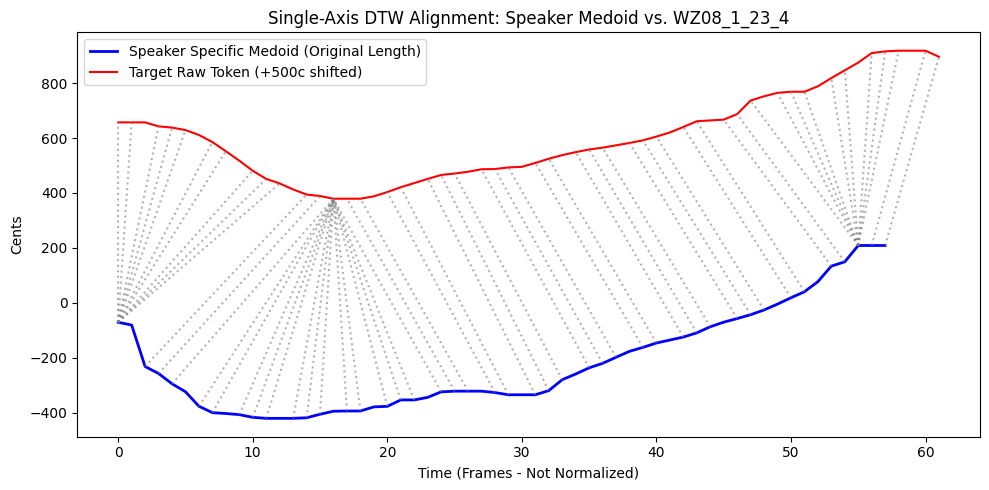

In [42]:
# --- DTW DIAGNOSTIC PLOT ---
# Visualizing how the DTW cleanly warped a raw speaker token against their *exact* Speaker Medoid
target = clean_filenames[0] 
if len(wz_outliers) > 0:
    target = wz_outliers[0][0] # use the worst outlier

# Lookup properties
lookup = plotting_refs[target]
raw_target_contour = lookup['raw']
its_speaker_medoid = lookup['medoid']

plot_dtw_single_axis(its_speaker_medoid, raw_target_contour, f"Single-Axis DTW Alignment: Speaker Medoid vs. {target}")


Random Target Token: WZ15_1_23_5
Its Speaker Medoid:  WZ15_1_6_5


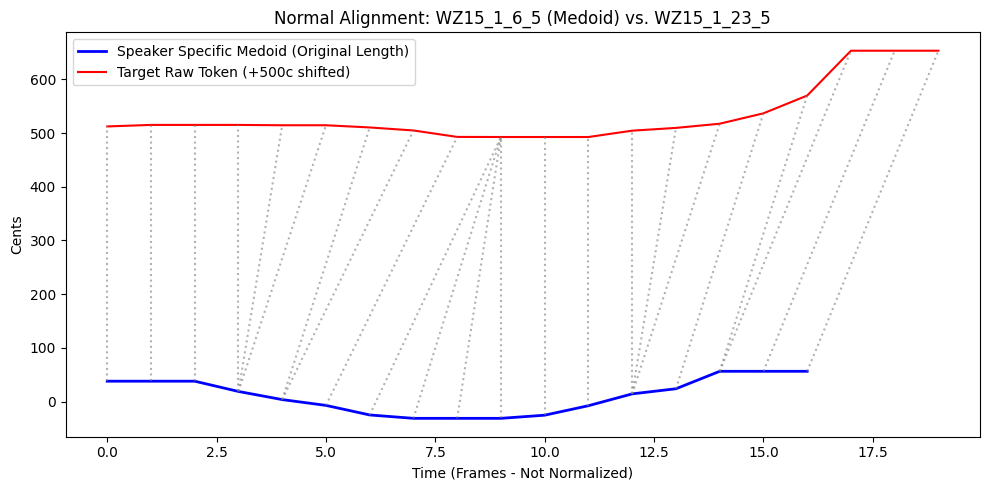

In [22]:
# Plot a random NORMAL token (not an outlier) against its Speaker Medoid to see a clean alignment example
import random
import numpy as np

# 1. Get a list of just the outlier filenames so we can avoid them
outlier_names = [item[0] for item in wz_outliers] 

# 2. Filter the main list to keep only the "normal" tokens
normal_tokens = [fname for fname in clean_filenames if fname not in outlier_names]

# 3. Pick one at random
random_target = random.choice(normal_tokens)

# 4. Lookup properties
lookup = plotting_refs[random_target]
raw_target_contour = lookup['raw']
its_speaker_medoid = lookup['medoid']

# 5. Reverse-lookup the medoid's actual filename!
# The medoid is simply the file whose 'raw' contour is identical to the 'medoid' contour
medoid_filename = "Unknown Medoid"
for fname, refs in plotting_refs.items():
    if np.array_equal(refs['raw'], its_speaker_medoid):
        medoid_filename = fname
        break

print(f"Random Target Token: {random_target}")
print(f"Its Speaker Medoid:  {medoid_filename}")

# 6. Plot it!
plot_title = f"Normal Alignment: {medoid_filename} (Medoid) vs. {random_target}"
plot_dtw_single_axis(its_speaker_medoid, raw_target_contour, plot_title)

--- Building Cross-Dialect Tone Matrix: DZ vs WZ ---

Harvesting DZ SHORT vowels...
Extracting Tone 1 (short vowels) from Tier 2 (N=98)...
✅ Extracted 98 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (short vowels) from Tier 2 (N=137)...
✅ Extracted 137 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 3 (short vowels) from Tier 2 (N=200)...
✅ Extracted 200 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 4 (short vowels) from Tier 2 (N=24)...
✅ Extracted 24 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}


/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_19308/2380738933.py:92: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(pitch_cents, kernel_size=5)


✅ Extracted 294 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 6, 'parselmouth_error': 0}
Extracting Tone 8 (short vowels) from Tier 2 (N=279)...


/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_19308/2380738933.py:90: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(interpolated, kernel_size=5)


✅ Extracted 271 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 8, 'parselmouth_error': 0}
Extracting Tone 9 (short vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 10 (short vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}

Harvesting WZ LONG vowels...
Extracting Tone 1 (long vowels) from Tier 2 (N=464)...
✅ Extracted 464 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (long vowels) from Tier 2 (N=293)...
✅ Extracted 293 contours.
Skipped breakdown: {'no_audio_fil

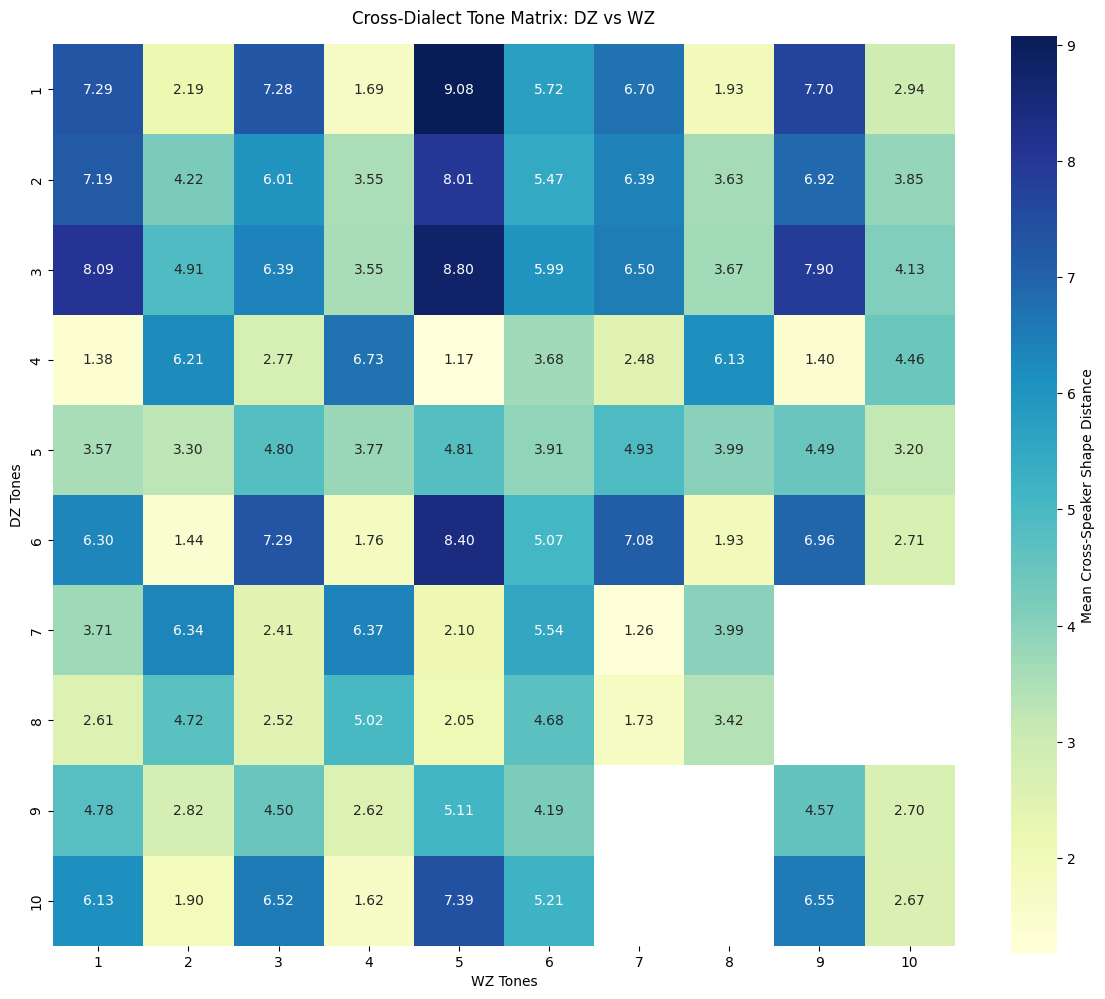

In [ ]:
# Similarity matrix comparing tones across dialects
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dtaidistance import dtw, dtw_barycenter

def get_medoid_index_fast(contours):
    """Uses the optimized C-backend to calculate the pairwise matrix instantly"""
    dist_matrix = dtw.distance_matrix(contours, parallel=True, use_c=True)
    full_matrix = dist_matrix + dist_matrix.T
    avg_dists = np.mean(full_matrix, axis=1)
    return np.argmin(avg_dists)

def build_cross_dialect_tone_matrix(dialect_a='DZ', dialect_b='WZ'):
    print(f"--- Building Cross-Dialect Tone Matrix: {dialect_a} vs {dialect_b} ---")
    
    # 1. Helper function to extract metadata for a specific dialect
    def get_dialect_meta(target_dialect):
        sub = df[(df['Dialect'] == target_dialect) & 
                 (df['Exclude'] == 'Keep') & 
                 (df['DictionaryMatch'] == 'yes')]
        tones = sorted([str(t) for t in sub['ReclassifiedTone'].unique() if str(t) != 'nan'], 
                       key=lambda x: int(x) if x.isdigit() else 99)
        speakers = sorted(list(set(sub['Speaker'].dropna())))
        return tones, speakers

    tones_a, spks_a = get_dialect_meta(dialect_a)
    tones_b, spks_b = get_dialect_meta(dialect_b)
    
    # 2. Master dictionary to hold prototypes for both dialects
    protos = {
        dialect_a: {spk: {'short': {}, 'long': {}} for spk in spks_a},
        dialect_b: {spk: {'short': {}, 'long': {}} for spk in spks_b}
    }
    
    # 3. HARVESTING LOOP (Runs once per Dialect/Length/Tone)
    for current_dialect, dialect_tones, dialect_spks in [(dialect_a, tones_a, spks_a), (dialect_b, tones_b, spks_b)]:
        for vl in ['short', 'long']:
            print(f"\nHarvesting {current_dialect} {vl.upper()} vowels...")
            for tone in dialect_tones:
                contours, fnames = get_dtw_contours_with_textgrids(current_dialect, tone, target_vl=vl)
                if len(contours) == 0:
                    continue
                
                # Distribute to the individual speakers of this dialect
                for spk in dialect_spks:
                    spk_contours = [c for c, f in zip(contours, fnames) if str(f).startswith(spk)]
                    if len(spk_contours) < 3: 
                        continue
                    
                    # Z-Normalize and build the speaker's personal prototype (DBA)
                    z_contours = [(c - np.mean(c)) / (np.std(c) + 1e-8) for c in spk_contours]
                    medoid_idx = get_medoid_index_fast(z_contours)
                    proto = dtw_barycenter.dba_loop(z_contours, c=z_contours[medoid_idx], max_it=3)
                    
                    protos[current_dialect][spk][vl][tone] = proto

    # 4. CROSS-DIALECT COMPARISON
    print(f"\nCross-comparing {dialect_a} speakers vs. {dialect_b} speakers (controlling for Vowel Length)...")
    
    # Setup matrices where Rows = Dialect A Tones, Columns = Dialect B Tones
    sum_matrix = pd.DataFrame(0.0, index=tones_a, columns=tones_b)
    count_matrix = pd.DataFrame(0.0, index=tones_a, columns=tones_b)
    
    for spk_a in spks_a:
        for spk_b in spks_b:
            # Strictly compare within the same vowel length category
            for vl in ['short', 'long']:
                
                # Iterate through all tones Dialect A speaker produced in this length
                for t_a, p_a in protos[dialect_a][spk_a][vl].items():
                    
                    # Iterate through all tones Dialect B speaker produced in this length
                    for t_b, p_b in protos[dialect_b][spk_b][vl].items():
                        
                        dist = dtw.distance(p_a, p_b)
                        sum_matrix.loc[t_a, t_b] += dist
                        count_matrix.loc[t_a, t_b] += 1

    # 5. AGGREGATION & VISUALIZATION
    print("Aggregating final matrix...")
    master_matrix = sum_matrix / count_matrix.replace(0, np.nan)
    master_matrix = master_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(master_matrix, annot=True, fmt=".2f", cmap="YlGnBu", 
                cbar_kws={'label': 'Mean Cross-Speaker Shape Distance'})
    
    plt.title(f"Cross-Dialect Tone Matrix: {dialect_a} vs {dialect_b}", pad=15)
    plt.ylabel(f"{dialect_a} Tones")
    plt.xlabel(f"{dialect_b} Tones")
    
    # If both dialects happen to have the exact same number of tone categories, make it a perfect square
    if len(master_matrix.index) == len(master_matrix.columns):
        plt.gca().set_aspect('equal')
        
    plt.tight_layout()
    plt.show()
    
    return master_matrix

# Start the cross-dialect mapping!
cross_dialect_matrix_dz_wz = build_cross_dialect_tone_matrix('DZ', 'WZ')

In [41]:
import sys
import subprocess

# Force install seaborn into the active Jupyter kernel, bypassing the macOS lock
subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn", "--break-system-packages"])
print("Seaborn successfully installed in the active kernel!")

Seaborn successfully installed in the active kernel!


--- Building Speaker Matrix: WZ Tone 6 (long vowels) ---
Extracting Tone 6 (long vowels) from Tier 2 (N=324)...
✅ Extracted 324 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Successfully harvested 324 tokens. Calculating distance matrix...


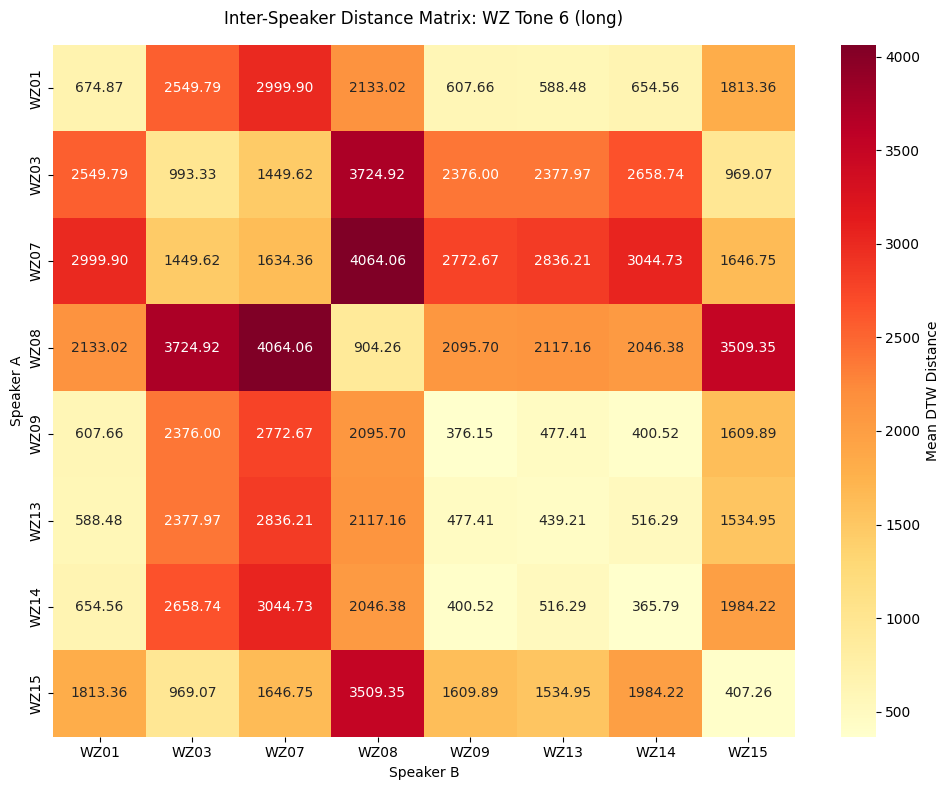

In [42]:
# Calculate the DTW distance matrix between speakers and visualize it as a heatmap
# Customize the combination of dialect, tone, and vowel length
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dtaidistance import dtw

def build_speaker_distance_matrix_fast(contours, filenames):
    """Optimized version using the C-backend for calculating pairwise token distances"""
    speakers = [fname[:4] for fname in filenames]
    unique_speakers = sorted(list(set(speakers)))
    
    # Calculate the entire pairwise matrix instantly using C
    dist_matrix = dtw.distance_matrix(contours, parallel=True, use_c=True)
    
    # Make it symmetric
    n = len(contours)
    for i in range(n):
        for j in range(i + 1, n):
            dist_matrix[j, i] = dist_matrix[i, j]
        dist_matrix[i, i] = 0.0
        
    dist_df = pd.DataFrame(index=unique_speakers, columns=unique_speakers, dtype=float)
    spk_indices = {spk: [i for i, s in enumerate(speakers) if s == spk] for spk in unique_speakers}
    
    for spk1 in unique_speakers:
        for spk2 in unique_speakers:
            # Mirror to save time
            if pd.notna(dist_df.loc[spk2, spk1]):
                dist_df.loc[spk1, spk2] = dist_df.loc[spk2, spk1]
                continue
                
            idx1 = spk_indices[spk1]
            idx2 = spk_indices[spk2]
            
            if not idx1 or not idx2:
                continue
                
            # Extract the cross-section of distances for just these two speakers
            submatrix = dist_matrix[np.ix_(idx1, idx2)]
            
            if spk1 == spk2:
                # Intra-speaker: Average everything EXCEPT the diagonal (comparing a token to itself)
                if len(idx1) > 1:
                    mask = ~np.eye(len(idx1), dtype=bool)
                    avg_dist = np.mean(submatrix[mask])
                else:
                    avg_dist = 0.0
            else:
                # Inter-speaker: Average the entire block
                avg_dist = np.mean(submatrix)
                
            dist_df.loc[spk1, spk2] = avg_dist
            
    return dist_df

def build_single_tone_speaker_matrix(target_dialect, target_tone, target_vl='long'):
    print(f"--- Building Speaker Matrix: {target_dialect} Tone {target_tone} ({target_vl} vowels) ---")
    
    # 1. Harvest the tokens for this specific tone
    contours, fnames = get_dtw_contours_with_textgrids(target_dialect, str(target_tone), target_vl=target_vl)
    
    if len(contours) == 0:
        print(f"No valid tokens found for Tone {target_tone} ({target_vl}).")
        return None
        
    print(f"Successfully harvested {len(contours)} tokens. Calculating distance matrix...")
    
    # 2. Run the fast C-backed speaker comparison
    matrix = build_speaker_distance_matrix_fast(contours, fnames)
    
    # 3. Visualize
    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap="YlOrRd", 
                cbar_kws={'label': 'Mean DTW Distance'})
    
    plt.title(f"Inter-Speaker Distance Matrix: {target_dialect} Tone {target_tone} ({target_vl})", pad=15)
    plt.ylabel("Speaker A")
    plt.xlabel("Speaker B")
    plt.tight_layout()
    plt.show()
    
    return matrix

# Run it by passing the specific tone as an argument!
wz_tone_matrix = build_single_tone_speaker_matrix('WZ', target_tone='6', target_vl='long')

--- Building MASTER Speaker Matrix for DZ (Simple Unweighted Mean) ---
Extracting Tone 1 (long vowels) from Tier 2 (N=301)...
✅ Extracted 301 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Added Tone 1 (long) as 1 structural category.
Extracting Tone 2 (long vowels) from Tier 2 (N=128)...
✅ Extracted 128 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Added Tone 2 (long) as 1 structural category.
Extracting Tone 3 (long vowels) from Tier 2 (N=223)...
✅ Extracted 223 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Added Tone 3 (long) as 1 structural category.
Extracting Tone 4 (long vowels) from Tier 2 (N=153)...
✅ Extracted 153 contours.
Skipped breakdown: {'no

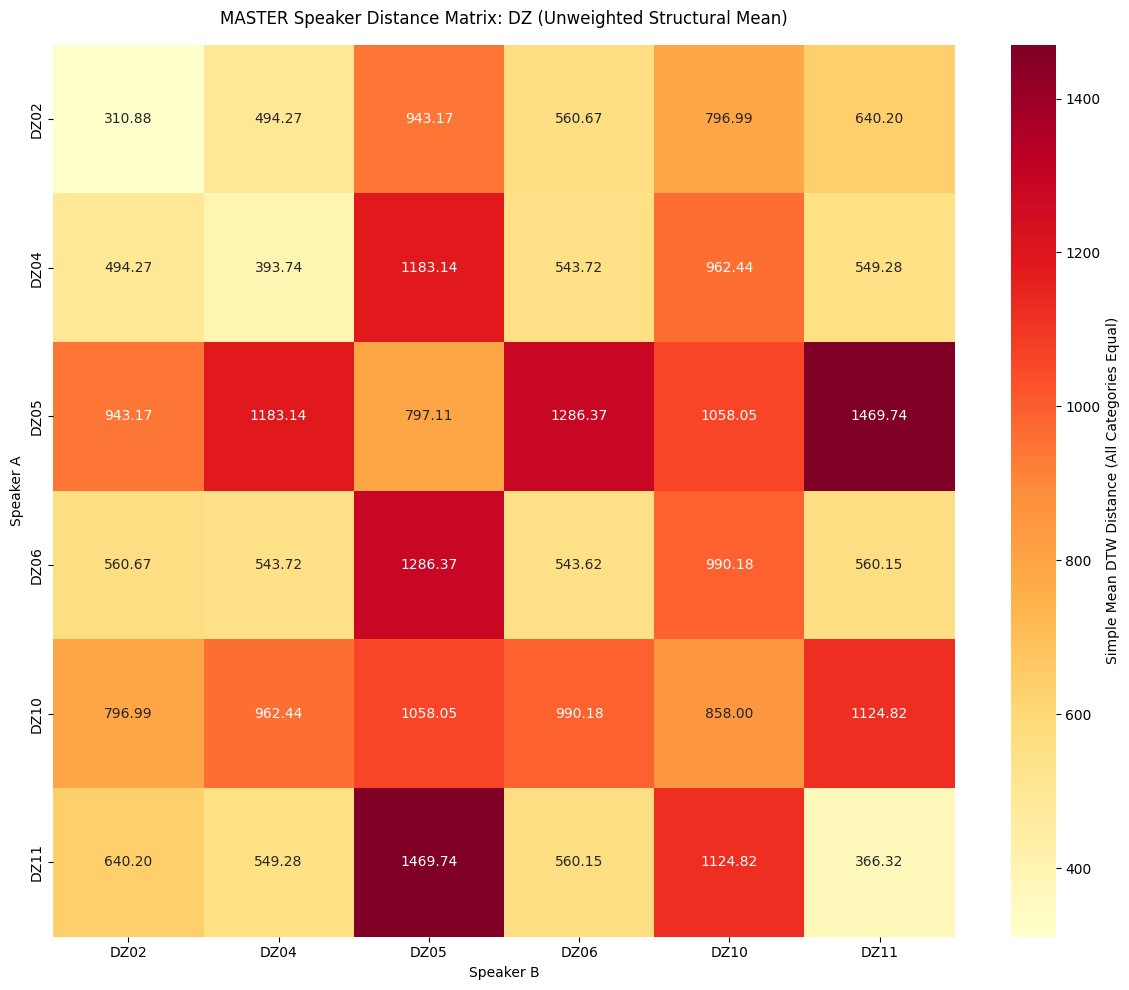

--- Building MASTER Speaker Matrix for WZ (Simple Unweighted Mean) ---
Extracting Tone 1 (long vowels) from Tier 2 (N=464)...
✅ Extracted 464 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Added Tone 1 (long) as 1 structural category.
Extracting Tone 2 (long vowels) from Tier 2 (N=293)...
✅ Extracted 293 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Added Tone 2 (long) as 1 structural category.
Extracting Tone 3 (long vowels) from Tier 2 (N=349)...
✅ Extracted 349 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Added Tone 3 (long) as 1 structural category.
Extracting Tone 4 (long vowels) from Tier 2 (N=154)...
✅ Extracted 154 contours.
Skipped breakdown: {'no

/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_19308/2380738933.py:92: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(pitch_cents, kernel_size=5)


✅ Extracted 294 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 6, 'parselmouth_error': 0}
Added Tone 7 (short) as 1 structural category.
Extracting Tone 8 (short vowels) from Tier 2 (N=279)...


/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_19308/2380738933.py:92: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(pitch_cents, kernel_size=5)
/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_19308/2380738933.py:90: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(interpolated, kernel_size=5)


✅ Extracted 271 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 8, 'parselmouth_error': 0}
Added Tone 8 (short) as 1 structural category.
Extracting Tone 9 (short vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}

Aggregating matrices cell-by-cell (Simple Mean)...


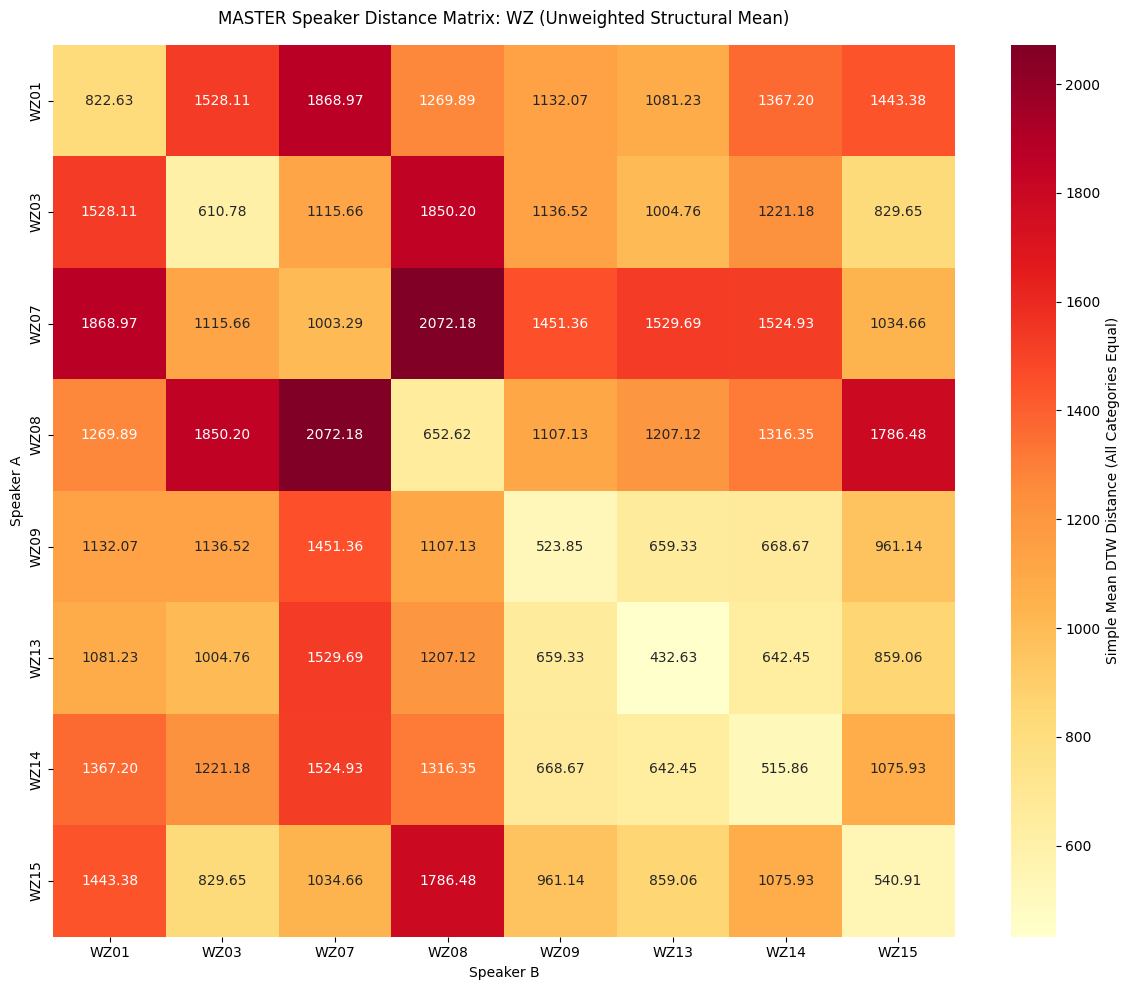

In [46]:
# Get overall speaker similarity by averaging the distances across all tone/length combinations, and visualize it as a heatmap
# Customize the dialect
def build_master_speaker_matrix(target_dialect):
    print(f"--- Building MASTER Speaker Matrix for {target_dialect} (Simple Unweighted Mean) ---")
    
    vowel_lengths = ['long', 'short']
    all_tones = sorted([str(t) for t in df['ReclassifiedTone'].unique() if str(t) != 'nan'], 
                       key=lambda x: int(x) if x.isdigit() else 99)
    
    # 1. Master Speaker List
    master_speakers = sorted(list(set(df[df['Dialect'] == target_dialect]['Speaker'].dropna())))
    
    # 2. Independent tracking matrices
    sum_matrix = pd.DataFrame(0.0, index=master_speakers, columns=master_speakers)
    count_matrix = pd.DataFrame(0.0, index=master_speakers, columns=master_speakers)
    
    for vl in vowel_lengths:
        for tone in all_tones:
            subset = df[(df['Dialect'] == target_dialect) & 
                        (df['ReclassifiedTone'] == tone) &
                        (df['VowelLength'] == vl) & 
                        (df['Exclude'] == 'Keep') &
                        (df['DictionaryMatch'] == 'yes')]
            
            if len(subset) < 3: 
                continue
                
            contours, fnames = get_dtw_contours_with_textgrids(target_dialect, tone, target_vl=vl)
            
            if len(contours) > 0:
                spk_matrix = build_speaker_distance_matrix_fast(contours, fnames)
                
                # 3. Safely add values cell-by-cell (Unweighted)
                for spk1 in spk_matrix.index:
                    for spk2 in spk_matrix.columns:
                        val = spk_matrix.loc[spk1, spk2]
                        if pd.notna(val):
                            sum_matrix.loc[spk1, spk2] += val
                            # Each successfully compared tone category counts as exactly 1 vote
                            count_matrix.loc[spk1, spk2] += 1 
                            
                print(f"Added Tone {tone} ({vl}) as 1 structural category.")
                
    # 4. Final calculation: Simple Mean
    print("\nAggregating matrices cell-by-cell (Simple Mean)...")
    master_matrix = sum_matrix / count_matrix.replace(0, np.nan)
    
    # Visualize the Master Matrix
    plt.figure(figsize=(12, 10))
    sns.heatmap(master_matrix, annot=True, fmt=".2f", cmap="YlOrRd", 
                cbar_kws={'label': 'Simple Mean DTW Distance (All Categories Equal)'})
    
    plt.title(f"MASTER Speaker Distance Matrix: {target_dialect} (Unweighted Structural Mean)", pad=15)
    plt.ylabel("Speaker A")
    plt.xlabel("Speaker B")
    plt.tight_layout()
    plt.show()
    
    return master_matrix

# Start the crunch for Wuming Zhuang
dz_master_matrix = build_master_speaker_matrix('DZ')
wz_master_matrix = build_master_speaker_matrix('WZ')

--- Comparing DZ Tone 5 vs Tone 7 (short vowels) ---

Harvesting Tone 5...
Extracting Tone 5 (short vowels) from Tier 2 (N=35)...
✅ Extracted 35 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}

Harvesting Tone 7...
Extracting Tone 7 (short vowels) from Tier 2 (N=265)...
✅ Extracted 265 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}

Calculating cross-speaker distances...


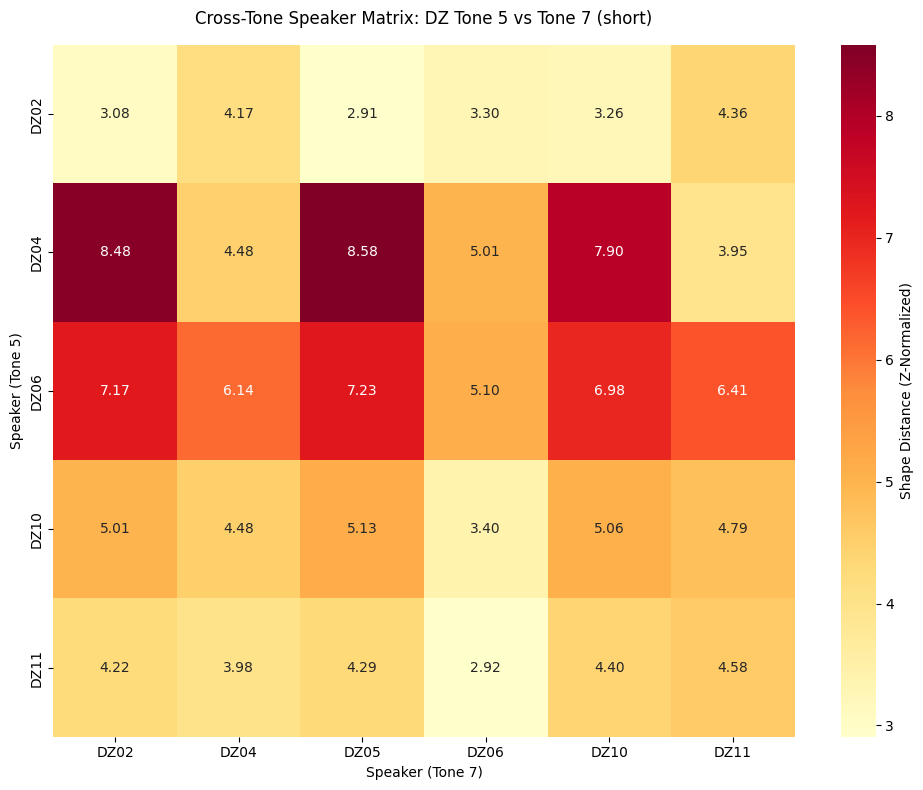

In [44]:
# For a given pair of tones, look at similarity across speakers
# Customize the dialect, vowel length and tones you want to compare across
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dtaidistance import dtw, dtw_barycenter

def get_medoid_index_fast(contours):
    """Uses the optimized C-backend to calculate the pairwise matrix instantly"""
    dist_matrix = dtw.distance_matrix(contours, parallel=True, use_c=True)
    full_matrix = dist_matrix + dist_matrix.T
    avg_dists = np.mean(full_matrix, axis=1)
    return np.argmin(avg_dists)

def build_cross_tone_speaker_matrix(target_dialect, tone_a, tone_b, target_vl='long'):
    print(f"--- Comparing {target_dialect} Tone {tone_a} vs Tone {tone_b} ({target_vl} vowels) ---")
    
    # 1. Get a master list of valid speakers for this dialect
    subset = df[(df['Dialect'] == target_dialect) & 
                (df['Exclude'] == 'Keep') &
                (df['DictionaryMatch'] == 'yes')]
    master_speakers = sorted(list(set(subset['Speaker'].dropna())))
    
    protos_a = {}
    protos_b = {}
    
    # 2. Harvest and build personal prototypes for Tone A
    print(f"\nHarvesting Tone {tone_a}...")
    contours_a, fnames_a = get_dtw_contours_with_textgrids(target_dialect, str(tone_a), target_vl)
    
    for spk in master_speakers:
        spk_c = [c for c, f in zip(contours_a, fnames_a) if str(f).startswith(spk)]
        if len(spk_c) >= 3:
            zc = [(c - np.mean(c)) / (np.std(c) + 1e-8) for c in spk_c]
            m_idx = get_medoid_index_fast(zc)
            protos_a[spk] = dtw_barycenter.dba_loop(zc, c=zc[m_idx], max_it=3)
            
    # 3. Harvest and build personal prototypes for Tone B
    print(f"\nHarvesting Tone {tone_b}...")
    contours_b, fnames_b = get_dtw_contours_with_textgrids(target_dialect, str(tone_b), target_vl)
    
    for spk in master_speakers:
        spk_c = [c for c, f in zip(contours_b, fnames_b) if str(f).startswith(spk)]
        if len(spk_c) >= 3:
            zc = [(c - np.mean(c)) / (np.std(c) + 1e-8) for c in spk_c]
            m_idx = get_medoid_index_fast(zc)
            protos_b[spk] = dtw_barycenter.dba_loop(zc, c=zc[m_idx], max_it=3)
            
    # 4. Cross-Compare Tone A vs. Tone B across Speakers
    valid_spk_a = sorted(list(protos_a.keys()))
    valid_spk_b = sorted(list(protos_b.keys()))
    
    if not valid_spk_a or not valid_spk_b:
        print("Not enough data to compare these two tones.")
        return None
        
    print("\nCalculating cross-speaker distances...")
    matrix = pd.DataFrame(np.nan, index=valid_spk_a, columns=valid_spk_b)
    
    for spk_a in valid_spk_a:
        for spk_b in valid_spk_b:
            dist = dtw.distance(protos_a[spk_a], protos_b[spk_b])
            matrix.loc[spk_a, spk_b] = dist
            
    # 5. Visualize
    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap="YlOrRd", 
                cbar_kws={'label': 'Shape Distance (Z-Normalized)'})
    
    plt.title(f"Cross-Tone Speaker Matrix: {target_dialect} Tone {tone_a} vs Tone {tone_b} ({target_vl})", pad=15)
    plt.ylabel(f"Speaker (Tone {tone_a})")
    plt.xlabel(f"Speaker (Tone {tone_b})")
    
    if len(matrix.index) == len(matrix.columns):
        plt.gca().set_aspect('equal')
        
    plt.tight_layout()
    plt.show()
    
    return matrix

# Run it with choice of dialect, tone pair and vowel length
tone_comparison_matrix = build_cross_tone_speaker_matrix(
    target_dialect='DZ', 
    tone_a='5', 
    tone_b='7', 
    target_vl='short'
)

--- Building Speaker-Controlled Inter-Tone Matrix for WZ (Duration Ignored) ---
Harvesting Tone 1 (pooling short & long vowels)...
Extracting Tone 1 (short vowels) from Tier 2 (N=193)...
✅ Extracted 193 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 1 (long vowels) from Tier 2 (N=464)...
✅ Extracted 464 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Harvesting Tone 2 (pooling short & long vowels)...
Extracting Tone 2 (short vowels) from Tier 2 (N=155)...
✅ Extracted 155 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (long vowels) from Tier 2 (N=293)...
✅ Extracted 293 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_text

/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_19308/2380738933.py:92: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(pitch_cents, kernel_size=5)


✅ Extracted 294 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 6, 'parselmouth_error': 0}
Extracting Tone 7 (long vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Harvesting Tone 8 (pooling short & long vowels)...
Extracting Tone 8 (short vowels) from Tier 2 (N=279)...


/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_19308/2380738933.py:90: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(interpolated, kernel_size=5)


✅ Extracted 271 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 8, 'parselmouth_error': 0}
Extracting Tone 8 (long vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Harvesting Tone 9 (pooling short & long vowels)...
Extracting Tone 9 (short vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 9 (long vowels) from Tier 2 (N=212)...
✅ Extracted 211 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 1, 'parselmouth_error': 0}
Harvesting Tone 10 (pooling short & long vowels)...
Extracting Tone 10 (short vowels) from Tier

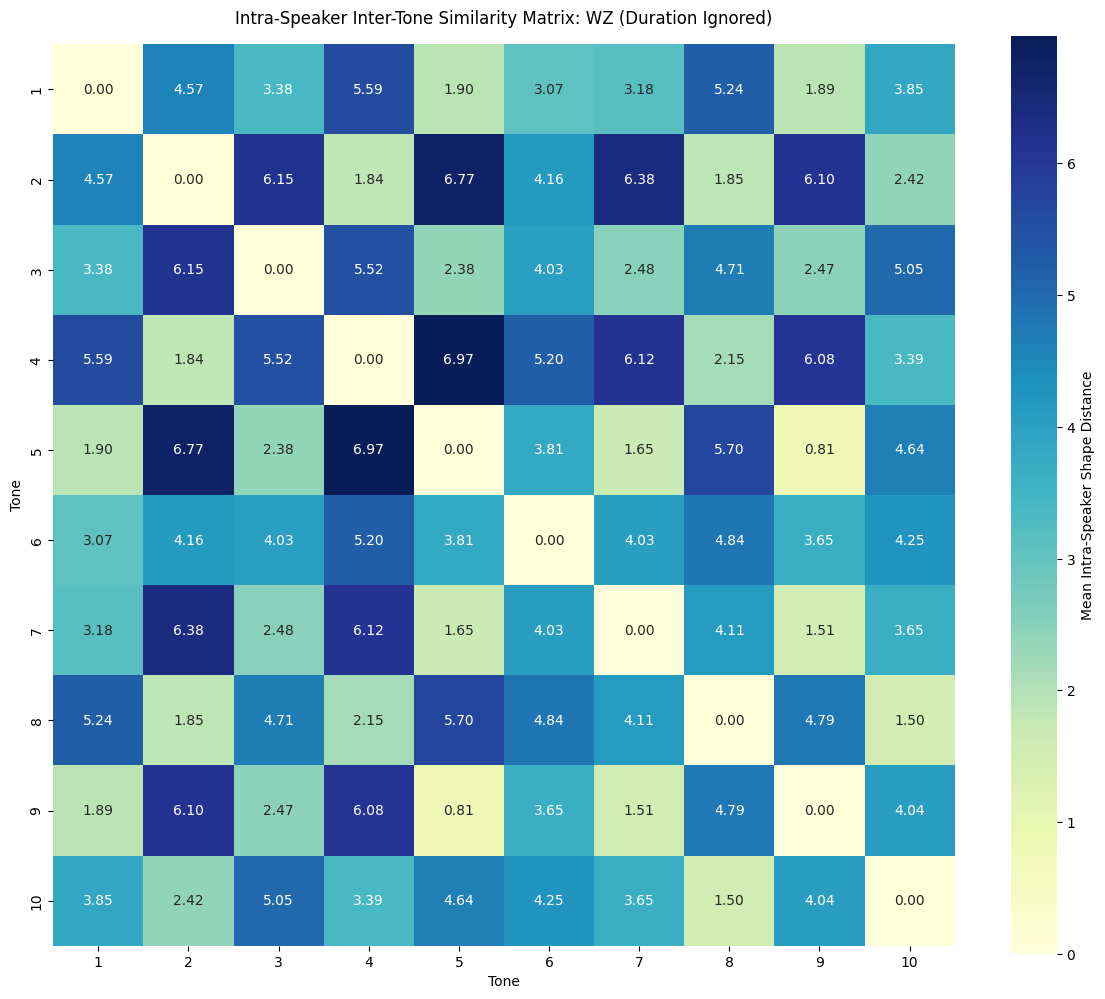

--- Building Speaker-Controlled Inter-Tone Matrix for DZ (Duration Ignored) ---
Harvesting Tone 1 (pooling short & long vowels)...
Extracting Tone 1 (short vowels) from Tier 2 (N=98)...
✅ Extracted 98 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 1 (long vowels) from Tier 2 (N=301)...
✅ Extracted 301 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Harvesting Tone 2 (pooling short & long vowels)...
Extracting Tone 2 (short vowels) from Tier 2 (N=137)...
✅ Extracted 137 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (long vowels) from Tier 2 (N=128)...
✅ Extracted 128 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgr

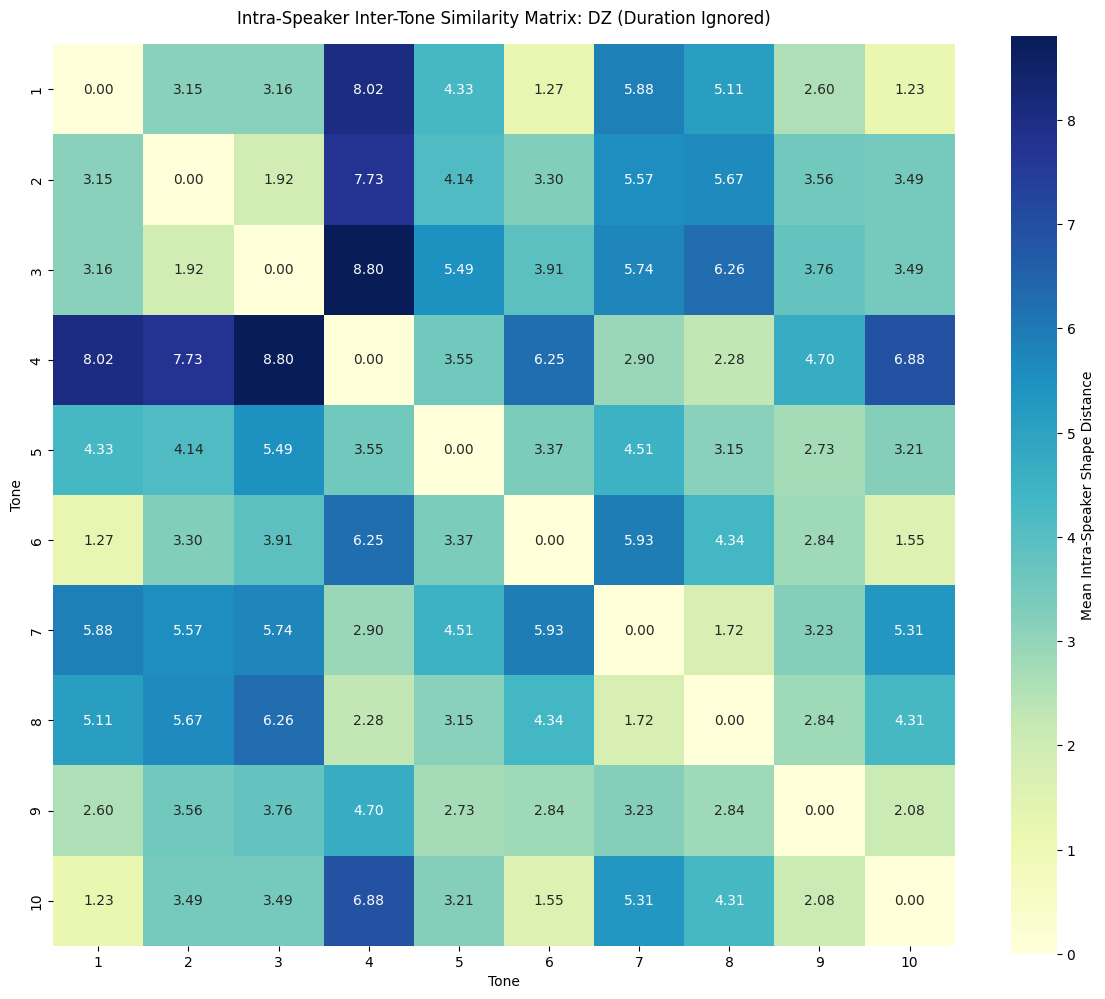

In [45]:
# Compare inter-tone similarity across speakers
# Customize the dialect
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dtaidistance import dtw, dtw_barycenter

def get_medoid_index_fast(contours):
    """Uses the optimized C-backend to calculate the pairwise matrix instantly"""
    dist_matrix = dtw.distance_matrix(contours, parallel=True, use_c=True)
    full_matrix = dist_matrix + dist_matrix.T
    avg_dists = np.mean(full_matrix, axis=1)
    return np.argmin(avg_dists)

def build_speaker_controlled_inter_tone_matrix(target_dialect):
    print(f"--- Building Speaker-Controlled Inter-Tone Matrix for {target_dialect} (Duration Ignored) ---")
    
    # 1. Get baseline data
    subset = df[(df['Dialect'] == target_dialect) & 
                (df['Exclude'] == 'Keep') &
                (df['DictionaryMatch'] == 'yes')]
    
    all_tones = sorted([str(t) for t in subset['ReclassifiedTone'].unique() if str(t) != 'nan'], 
                       key=lambda x: int(x) if x.isdigit() else 99)
    master_speakers = sorted(list(set(subset['Speaker'].dropna())))
    
    # Initialize a master dictionary to hold every speaker's unified prototypes
    spk_protos = {spk: {} for spk in master_speakers}
    
    # 2. HARVEST ONCE (Pooling both lengths)
    for tone in all_tones:
        print(f"Harvesting Tone {tone} (pooling short & long vowels)...")
        
        all_tone_contours = []
        all_tone_fnames = []
        
        # Safely pull and pool both lengths using your existing harvester
        for vl in ['short', 'long']:
            contours, fnames = get_dtw_contours_with_textgrids(target_dialect, tone, target_vl=vl)
            all_tone_contours.extend(contours)
            all_tone_fnames.extend(fnames)
            
        if len(all_tone_contours) == 0:
            continue
            
        # Distribute the pooled data to the individual speakers
        for spk in master_speakers:
            spk_contours = [c for c, f in zip(all_tone_contours, all_tone_fnames) if str(f).startswith(spk)]
            
            if len(spk_contours) < 3: # Need at least 3 combined tokens for a valid prototype
                continue
            
            # Z-Normalize and build the unified personal prototype
            z_contours = [(c - np.mean(c)) / (np.std(c) + 1e-8) for c in spk_contours]
            medoid_idx = get_medoid_index_fast(z_contours)
            proto = dtw_barycenter.dba_loop(z_contours, c=z_contours[medoid_idx], max_it=3)
            
            spk_protos[spk][tone] = proto
            
    # 3. CROSS-COMPARE within each speaker's personal geometry
    print("\nCross-comparing intra-speaker prototypes...")
    sum_matrix = pd.DataFrame(0.0, index=all_tones, columns=all_tones)
    count_matrix = pd.DataFrame(0.0, index=all_tones, columns=all_tones)
    
    for spk in master_speakers:
        tones_present = list(spk_protos[spk].keys())
        
        # Compare every valid tone against every other valid tone for this speaker
        for t1, t2 in itertools.combinations_with_replacement(tones_present, 2):
            dist = dtw.distance(spk_protos[spk][t1], spk_protos[spk][t2])
            
            # Since Tone 1 vs Tone 2 is identical to Tone 2 vs Tone 1, mirror the results
            sum_matrix.loc[t1, t2] += dist
            count_matrix.loc[t1, t2] += 1
            
            if t1 != t2:
                sum_matrix.loc[t2, t1] += dist
                count_matrix.loc[t2, t1] += 1
                
    # 4. Calculate Final Averages
    print("Aggregating final matrix...")
    master_matrix = sum_matrix / count_matrix.replace(0, np.nan)
    master_matrix = master_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')
    
    # 5. Visualize
    plt.figure(figsize=(12, 10))
    sns.heatmap(master_matrix, annot=True, fmt=".2f", cmap="YlGnBu", 
                cbar_kws={'label': 'Mean Intra-Speaker Shape Distance'})
    
    plt.title(f"Intra-Speaker Inter-Tone Similarity Matrix: {target_dialect} (Duration Ignored)", pad=15)
    plt.ylabel("Tone")
    plt.xlabel("Tone")
    
    # Force a perfect square since axes are identical
    plt.gca().set_aspect('equal')
    plt.tight_layout()
    plt.show()
    
    return master_matrix

# Run it for both dialects
pure_tone_matrix_wz = build_speaker_controlled_inter_tone_matrix('WZ')
pure_tone_matrix_dz = build_speaker_controlled_inter_tone_matrix('DZ')

--- Building Speaker-Controlled Cross-Length Matrix for DZ (Using 100% of data) ---

Harvesting all SHORT vowels...
Extracting Tone 1 (short vowels) from Tier 2 (N=98)...
✅ Extracted 98 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (short vowels) from Tier 2 (N=137)...
✅ Extracted 137 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 3 (short vowels) from Tier 2 (N=200)...
✅ Extracted 200 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 4 (short vowels) from Tier 2 (N=24)...
✅ Extracted 24 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_sho

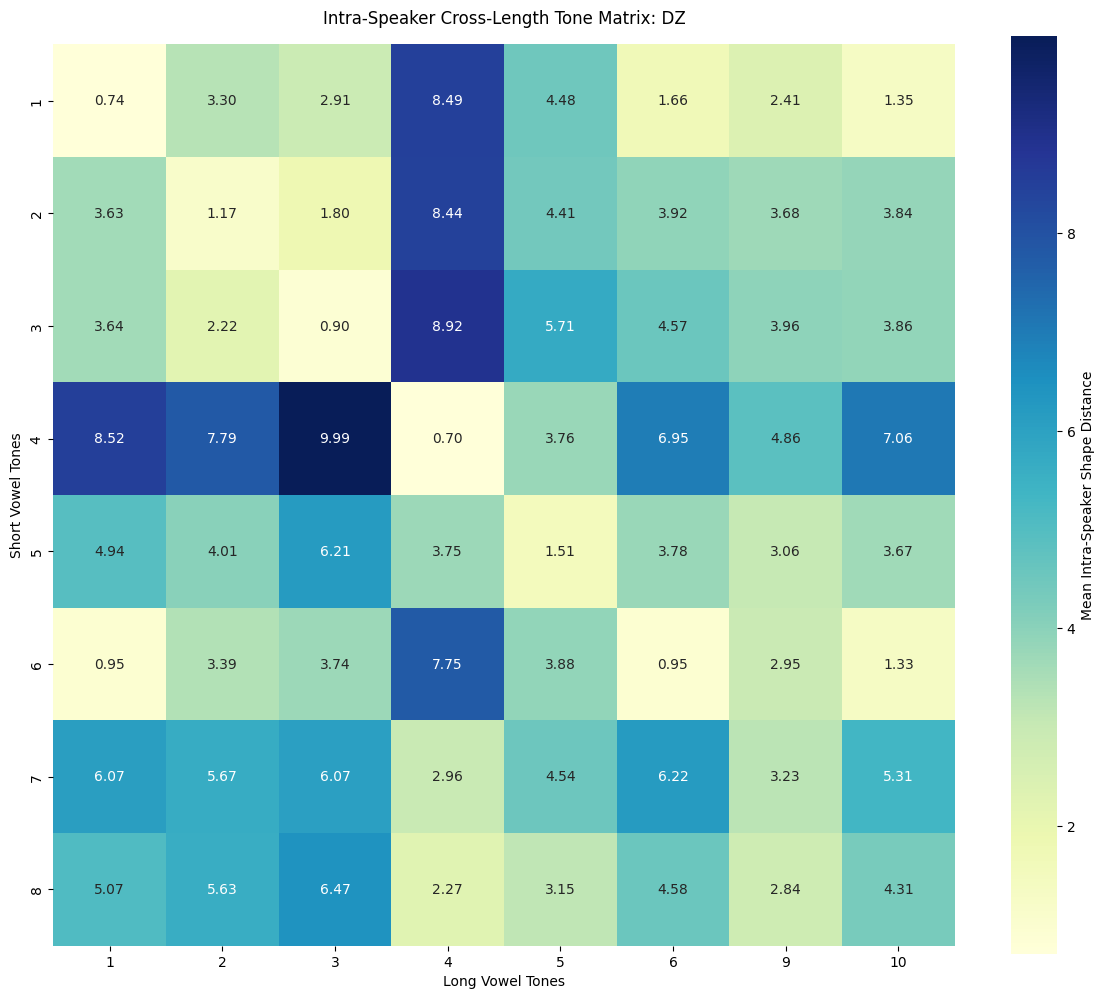

In [32]:
# Look at inter-tone similarity comparing short tones against long tones
# Customize by dialect
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dtaidistance import dtw, dtw_barycenter

def get_medoid_index_fast(contours):
    """Uses the optimized C-backend to calculate the pairwise matrix instantly"""
    dist_matrix = dtw.distance_matrix(contours, parallel=True, use_c=True)
    full_matrix = dist_matrix + dist_matrix.T
    avg_dists = np.mean(full_matrix, axis=1)
    return np.argmin(avg_dists)

def build_speaker_controlled_cross_length_matrix(target_dialect):
    print(f"--- Building Speaker-Controlled Cross-Length Matrix for {target_dialect} (Using 100% of data) ---")
    
    # 1. Get baseline data
    subset = df[(df['Dialect'] == target_dialect) & 
                (df['Exclude'] == 'Keep') &
                (df['DictionaryMatch'] == 'yes')]
    
    all_tones = sorted([str(t) for t in subset['ReclassifiedTone'].unique() if str(t) != 'nan'], 
                       key=lambda x: int(x) if x.isdigit() else 99)
    master_speakers = sorted(list(set(subset['Speaker'].dropna())))
    
    # Initialize a master dictionary to hold every speaker's prototypes
    spk_protos = {spk: {'short': {}, 'long': {}} for spk in master_speakers}
    
    # 2. OPTIMIZATION: Loop by Tone/Length FIRST, harvest ONCE
    for vl in ['short', 'long']:
        print(f"\nHarvesting all {vl.upper()} vowels...")
        for tone in all_tones:
            # Harvest the entire dialect for this specific tone/length combination
            contours, fnames = get_dtw_contours_with_textgrids(target_dialect, tone, target_vl=vl)
            
            if len(contours) == 0:
                continue
                
            # Now, distribute the harvested data to the individual speakers
            for spk in master_speakers:
                spk_contours = [c for c, f in zip(contours, fnames) if str(f).startswith(spk)]
                
                if len(spk_contours) < 3: # Need at least 3 tokens for a valid prototype
                    continue
                
                # Z-Normalize and build prototype
                z_contours = [(c - np.mean(c)) / (np.std(c) + 1e-8) for c in spk_contours]
                
                # Fast medoid calculation
                medoid_idx = get_medoid_index_fast(z_contours)
                
                # Calculate Barycenter (keeping max_it=3 as it converges quickly)
                proto = dtw_barycenter.dba_loop(z_contours, c=z_contours[medoid_idx], max_it=3)
                spk_protos[spk][vl][tone] = proto
                
    # 3. Cross-compare within each speaker's personal geometry
    print("\nCross-comparing intra-speaker prototypes...")
    sum_matrix = pd.DataFrame(0.0, index=all_tones, columns=all_tones)
    count_matrix = pd.DataFrame(0.0, index=all_tones, columns=all_tones)
    
    for spk in master_speakers:
        for t_short, p_short in spk_protos[spk]['short'].items():
            for t_long, p_long in spk_protos[spk]['long'].items():
                dist = dtw.distance(p_short, p_long)
                sum_matrix.loc[t_short, t_long] += dist
                count_matrix.loc[t_short, t_long] += 1
                
    # 4. Calculate Final Averages
    print("Aggregating final matrix...")
    master_matrix = sum_matrix / count_matrix.replace(0, np.nan)
    master_matrix = master_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')
    
    # 5. Visualize
    plt.figure(figsize=(12, 10))
    sns.heatmap(master_matrix, annot=True, fmt=".2f", cmap="YlGnBu", 
                cbar_kws={'label': 'Mean Intra-Speaker Shape Distance'})
    
    plt.title(f"Intra-Speaker Cross-Length Tone Matrix: {target_dialect}", pad=15)
    plt.ylabel("Short Vowel Tones")
    plt.xlabel("Long Vowel Tones")
    
    if len(master_matrix.index) == len(master_matrix.columns):
        plt.gca().set_aspect('equal')
        
    plt.tight_layout()
    plt.show()
    
    return master_matrix

# Run it!
speaker_controlled_matrix = build_speaker_controlled_cross_length_matrix('DZ')

--- Calculating Tonal Dispersion for WZ (long vowels) ---
Extracting Tone 1 (long vowels) from Tier 2 (N=464)...
✅ Extracted 464 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (long vowels) from Tier 2 (N=293)...
✅ Extracted 293 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 3 (long vowels) from Tier 2 (N=349)...
✅ Extracted 349 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 4 (long vowels) from Tier 2 (N=154)...
✅ Extracted 154 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 5 (long vo

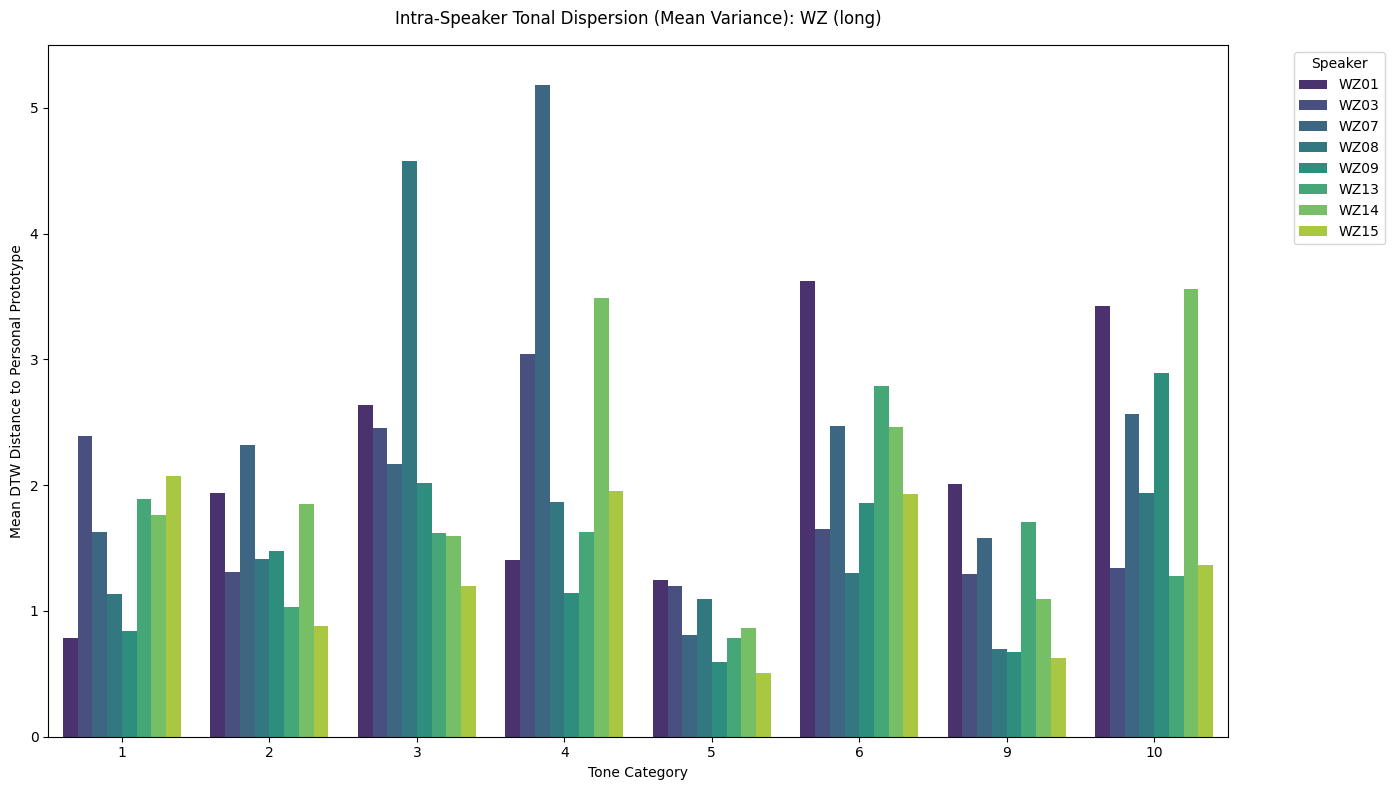

In [51]:
# Dispersion spread for each tone category, comparing how tightly clustered each speaker's tokens
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dtaidistance import dtw

def get_medoid_index_fast(contours):
    """Uses the optimized C-backend to calculate the pairwise matrix instantly"""
    dist_matrix = dtw.distance_matrix(contours, parallel=True, use_c=True)
    full_matrix = dist_matrix + dist_matrix.T
    avg_dists = np.mean(full_matrix, axis=1)
    return np.argmin(avg_dists)

def calculate_tonal_dispersion(target_dialect, target_vl='long'):
    print(f"--- Calculating Tonal Dispersion for {target_dialect} ({target_vl} vowels) ---")
    
    subset = df[(df['Dialect'] == target_dialect) & 
                (df['Exclude'] == 'Keep') &
                (df['DictionaryMatch'] == 'yes') &
                (df['VowelLength'] == target_vl)]
                
    master_speakers = sorted(list(set(subset['Speaker'].dropna())))
    all_tones = sorted([str(t) for t in subset['ReclassifiedTone'].unique() if str(t) != 'nan'], 
                       key=lambda x: int(x) if x.isdigit() else 99)
                       
    dispersion_records = []
    
    for tone in all_tones:
        contours, fnames = get_dtw_contours_with_textgrids(target_dialect, tone, target_vl)
        if len(contours) == 0: 
            continue
            
        for spk in master_speakers:
            spk_c = [c for c, f in zip(contours, fnames) if str(f).startswith(spk)]
            
            # Need at least 3 tokens to find a meaningful center and measure variance
            if len(spk_c) < 3: 
                continue
                
            # Z-Normalize
            zc = [(c - np.mean(c)) / (np.std(c) + 1e-8) for c in spk_c]
            
            # Find the medoid
            m_idx = get_medoid_index_fast(zc)
            medoid = zc[m_idx]
            
            # Calculate dispersion (mean distance of all tokens to the medoid)
            distances = [dtw.distance(c, medoid) for c in zc]
            mean_dispersion = np.mean(distances)
            
            dispersion_records.append({
                'Speaker': spk,
                'Tone': tone,
                'Dispersion': mean_dispersion,
                'TokenCount': len(spk_c)
            })
            
    disp_df = pd.DataFrame(dispersion_records)
    
    # Visualize as a grouped bar chart
    plt.figure(figsize=(14, 8))
    sns.barplot(data=disp_df, x='Tone', y='Dispersion', hue='Speaker', palette='viridis')
    plt.title(f"Intra-Speaker Tonal Dispersion (Mean Variance): {target_dialect} ({target_vl})", pad=15)
    plt.ylabel("Mean DTW Distance to Personal Prototype")
    plt.xlabel("Tone Category")
    plt.ylim(0, 5.5) # Or whatever the absolute maximum dispersion was across all your runs
    plt.legend(title='Speaker', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    return disp_df

# Check dispersion by dialect & vowel length
dispersion = calculate_tonal_dispersion('WZ', 'long')

--- Calculating Tonal Dispersion (Median) for WZ (long vowels) ---
Extracting Tone 1 (long vowels) from Tier 2 (N=464)...
✅ Extracted 464 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (long vowels) from Tier 2 (N=293)...
✅ Extracted 293 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 3 (long vowels) from Tier 2 (N=349)...
✅ Extracted 349 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 4 (long vowels) from Tier 2 (N=154)...
✅ Extracted 154 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 5

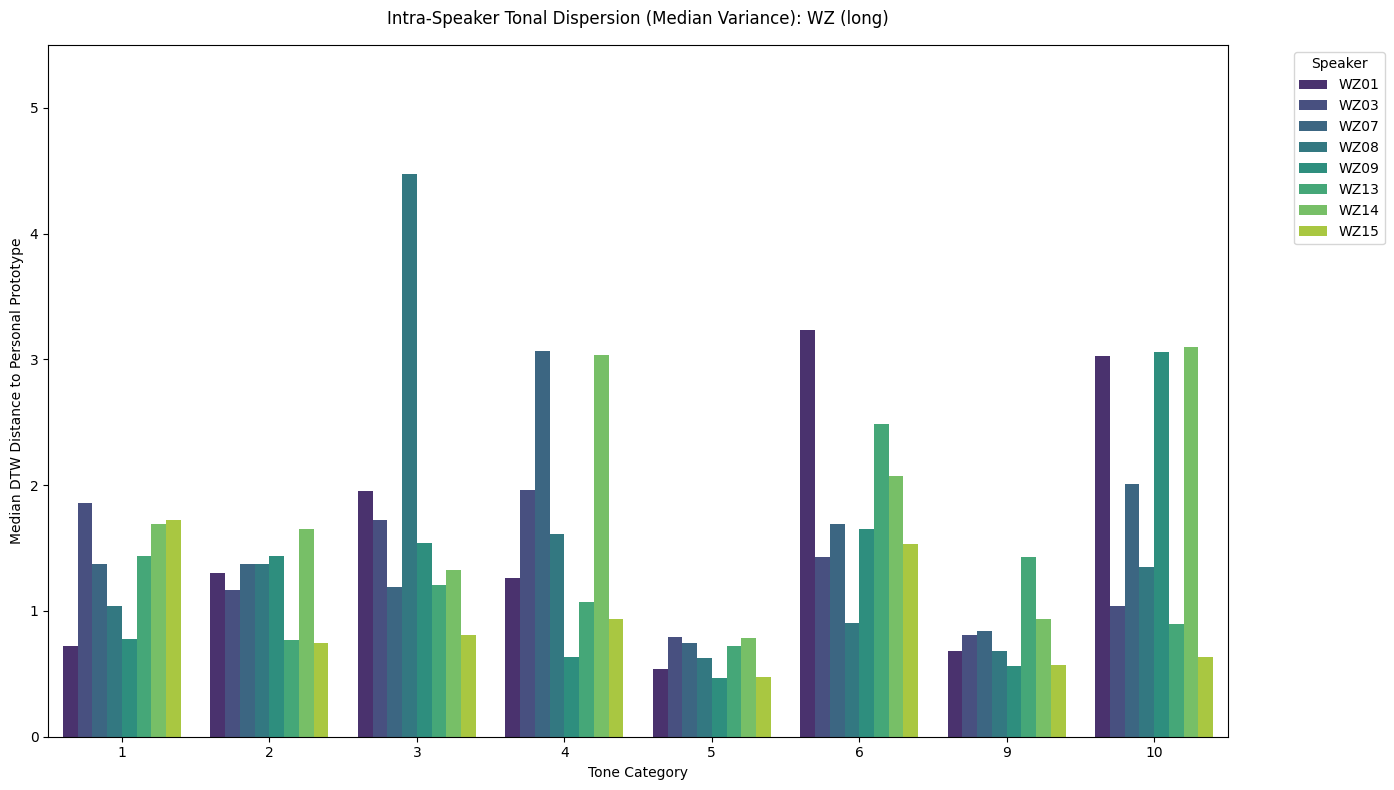

In [52]:
# The above code uses mean dispersion
# This is highly sensitive to outliers in tones with few tokens (i.e. tone 4 short)
# Try with median dispersion instead to see if it gives a more stable picture across all tones
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dtaidistance import dtw

def get_medoid_index_fast(contours):
    """Uses the optimized C-backend to calculate the pairwise matrix instantly"""
    dist_matrix = dtw.distance_matrix(contours, parallel=True, use_c=True)
    full_matrix = dist_matrix + dist_matrix.T
    avg_dists = np.mean(full_matrix, axis=1)
    return np.argmin(avg_dists)

def calculate_tonal_dispersion_median(target_dialect, target_vl='long'):
    print(f"--- Calculating Tonal Dispersion (Median) for {target_dialect} ({target_vl} vowels) ---")
    
    subset = df[(df['Dialect'] == target_dialect) & 
                (df['Exclude'] == 'Keep') &
                (df['DictionaryMatch'] == 'yes') &
                (df['VowelLength'] == target_vl)]
                
    master_speakers = sorted(list(set(subset['Speaker'].dropna())))
    all_tones = sorted([str(t) for t in subset['ReclassifiedTone'].unique() if str(t) != 'nan'], 
                       key=lambda x: int(x) if x.isdigit() else 99)
                       
    dispersion_records = []
    
    for tone in all_tones:
        contours, fnames = get_dtw_contours_with_textgrids(target_dialect, tone, target_vl)
        if len(contours) == 0: 
            continue
            
        for spk in master_speakers:
            spk_c = [c for c, f in zip(contours, fnames) if str(f).startswith(spk)]
            
            # Still require at least 3 tokens to find a meaningful center
            if len(spk_c) < 3: 
                continue
                
            # Z-Normalize
            zc = [(c - np.mean(c)) / (np.std(c) + 1e-8) for c in spk_c]
            
            # Find the medoid
            m_idx = get_medoid_index_fast(zc)
            medoid = zc[m_idx]
            
            # --- THE FIX: CALCULATE MEDIAN DISTANCE ---
            distances = [dtw.distance(c, medoid) for c in zc]
            median_dispersion = np.median(distances)
            # ------------------------------------------
            
            dispersion_records.append({
                'Speaker': spk,
                'Tone': tone,
                'Dispersion': median_dispersion,
                'TokenCount': len(spk_c)
            })
            
    disp_df = pd.DataFrame(dispersion_records)
    
    # Visualize as a grouped bar chart
    plt.figure(figsize=(14, 8))
    sns.barplot(data=disp_df, x='Tone', y='Dispersion', hue='Speaker', palette='viridis')
    plt.title(f"Intra-Speaker Tonal Dispersion (Median Variance): {target_dialect} ({target_vl})", pad=15)
    plt.ylabel("Median DTW Distance to Personal Prototype")
    plt.xlabel("Tone Category")
    plt.ylim(0, 5.5) # Or whatever the absolute maximum dispersion was across all your runs
    plt.legend(title='Speaker', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    return disp_df

# Check dispersion by dialect & vowel length using median instead of mean
dispersion_short_median = calculate_tonal_dispersion_median('WZ', 'long')

--- Calculating Universal Speaker Volatility (Raw Cents, Mean Aggregation) ---
Extracting Tone 1 (short vowels) from Tier 2 (N=98)...
✅ Extracted 98 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 1 (long vowels) from Tier 2 (N=301)...
✅ Extracted 301 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (short vowels) from Tier 2 (N=137)...
✅ Extracted 137 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (long vowels) from Tier 2 (N=128)...
✅ Extracted 128 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extra

/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_19308/2380738933.py:92: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(pitch_cents, kernel_size=5)


✅ Extracted 294 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 6, 'parselmouth_error': 0}
Extracting Tone 7 (long vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 8 (short vowels) from Tier 2 (N=279)...


/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_19308/2380738933.py:90: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(interpolated, kernel_size=5)


✅ Extracted 271 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 8, 'parselmouth_error': 0}
Extracting Tone 8 (long vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 9 (short vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 9 (long vowels) from Tier 2 (N=212)...
✅ Extracted 211 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 1, 'parselmouth_error': 0}
Extracting Tone 10 (short vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tie

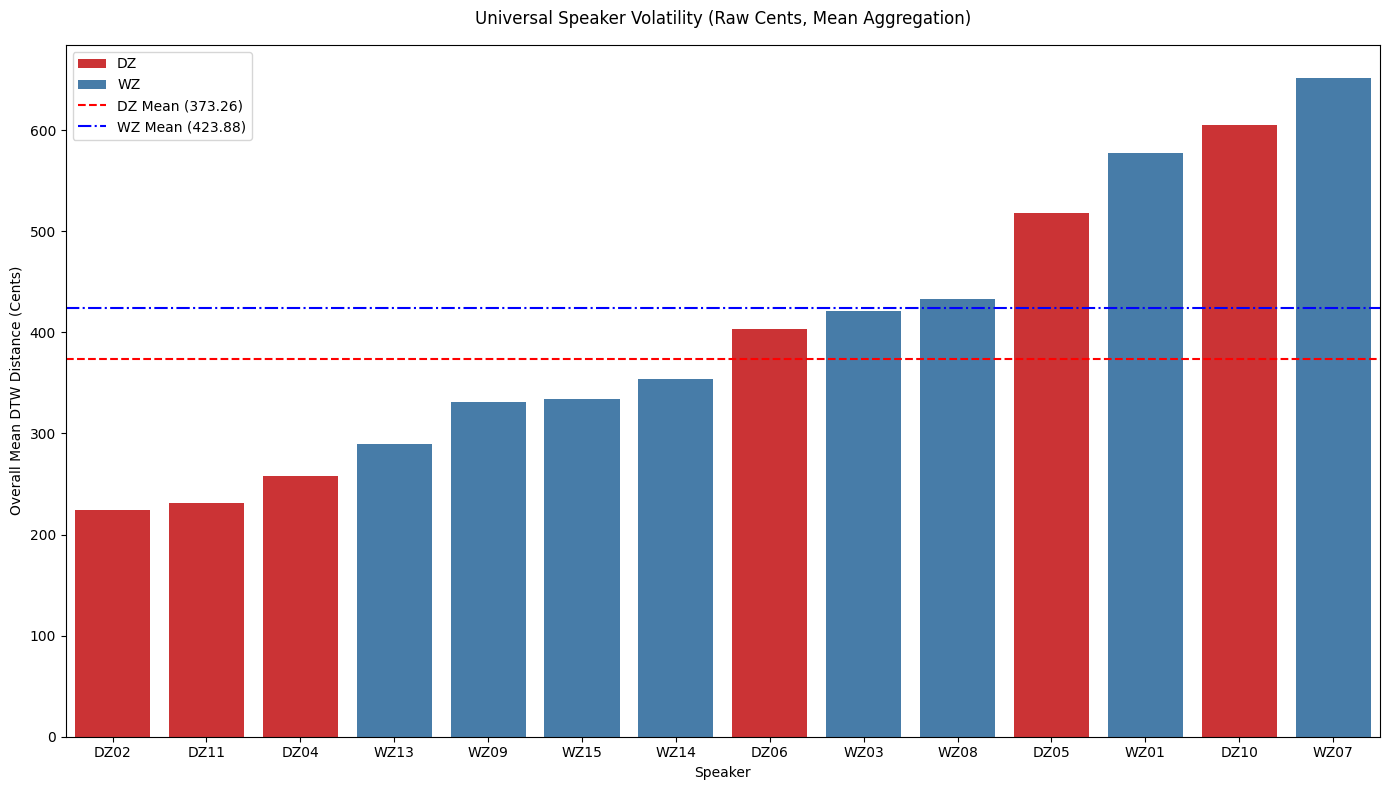

DZ records: 60
WZ records: 80


In [60]:
# Dispersion by speaker, across dialect, tones & vowel lengths
# using the mean instead of the median to see how outliers might be affecting the picture
# We also compare to the medoid instead of to each other point, to be consistent with the inter-speaker distance calculations which also use medoids as central points
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dtaidistance import dtw

def plot_universal_speaker_variance_raw_cents():
    print("--- Calculating Universal Speaker Volatility (Raw Cents, Mean Aggregation) ---")
    
    subset = df[(df['Exclude'] == 'Keep') & (df['DictionaryMatch'] == 'yes')]
    master_speakers = sorted(list(set(subset['Speaker'].dropna())))
    speaker_dialects = subset.drop_duplicates('Speaker').set_index('Speaker')['Dialect'].to_dict()
    
    dispersion_records = []
    
    for dialect in ['DZ', 'WZ']:
        dialect_subset = subset[subset['Dialect'] == dialect]
        all_tones = sorted([str(t) for t in dialect_subset['ReclassifiedTone'].unique() if str(t) != 'nan'], 
                           key=lambda x: int(x) if x.isdigit() else 99)
                           
        for tone in all_tones:
            all_tone_contours = []
            all_tone_fnames = []
            
            for vl in ['short', 'long']:
                contours, fnames = get_dtw_contours_with_textgrids(dialect, tone, target_vl=vl)
                all_tone_contours.extend(contours)
                all_tone_fnames.extend(fnames)
                
            if len(all_tone_contours) == 0: 
                continue
                
            dialect_speakers = [s for s in master_speakers if speaker_dialects.get(s) == dialect]
            
            for spk in dialect_speakers:
                spk_c = [c for c, f in zip(all_tone_contours, all_tone_fnames) if str(f).startswith(spk)]
                if len(spk_c) < 3: 
                    continue
                    
                # NO Z-NORMALIZATION! 
                # Passing the raw cents contours directly to the medoid calculator
                m_idx = get_medoid_index_fast(spk_c)
                medoid = spk_c[m_idx]
                
                # Calculate distances using raw cents
                distances = [dtw.distance(c, medoid) for c in spk_c]
                
                # Using mean to capture outlier severity
                mean_dispersion = np.mean(distances)
                
                dispersion_records.append({
                    'Speaker': spk,
                    'Dialect': dialect,
                    'Tone': tone,
                    'Dispersion': mean_dispersion
                })
                
    disp_df = pd.DataFrame(dispersion_records)
    
    # Using mean for final aggregation
    speaker_overall = disp_df.groupby(['Speaker', 'Dialect'])['Dispersion'].mean().reset_index()
    speaker_overall = speaker_overall.sort_values('Dispersion')
    
    # Visualization
    plt.figure(figsize=(14, 8))
    sns.barplot(data=speaker_overall, x='Speaker', y='Dispersion', hue='Dialect', palette='Set1', dodge=False)
    
    # Add Dialect Mean Lines
    dz_mean = speaker_overall[speaker_overall['Dialect'] == 'DZ']['Dispersion'].mean()
    wz_mean = speaker_overall[speaker_overall['Dialect'] == 'WZ']['Dispersion'].mean()
    
    plt.axhline(dz_mean, color='red', linestyle='--', label=f'DZ Mean ({dz_mean:.2f})')
    plt.axhline(wz_mean, color='blue', linestyle='-.', label=f'WZ Mean ({wz_mean:.2f})')
    
    plt.title("Universal Speaker Volatility (Raw Cents, Mean Aggregation)", pad=15)
    plt.ylabel("Overall Mean DTW Distance (Cents)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return disp_df

# Run the raw-cents volatility script!
raw_dispersion_df = plot_universal_speaker_variance_raw_cents()

# Create the dialect-specific subsets needed for the complexity and crowding tests
pure_dispersion_dz = raw_dispersion_df[raw_dispersion_df['Dialect'] == 'DZ']
pure_dispersion_wz = raw_dispersion_df[raw_dispersion_df['Dialect'] == 'WZ']

# Optional: Verify the shapes to ensure data was captured
print(f"DZ records: {len(pure_dispersion_dz)}")
print(f"WZ records: {len(pure_dispersion_wz)}")


In [49]:
import sys
import subprocess

# Install statsmodels safely into the current environment
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "statsmodels", "--break-system-packages"])

0

In [50]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from dtaidistance import dtw

def calculate_tonal_dispersion_all_lengths(target_dialect):
    print(f"--- Calculating Tonal Dispersion for {target_dialect} (Both Vowel Lengths) ---")
    
    subset = df[(df['Dialect'] == target_dialect) & 
                (df['Exclude'] == 'Keep') &
                (df['DictionaryMatch'] == 'yes')]
                
    master_speakers = sorted(list(set(subset['Speaker'].dropna())))
    all_tones = sorted([str(t) for t in subset['ReclassifiedTone'].unique() if str(t) != 'nan'], 
                       key=lambda x: int(x) if x.isdigit() else 99)
                       
    dispersion_records = []
    
    # Iterate through BOTH lengths independently so targets aren't cross-contaminated
    for vl in ['short', 'long']:
        for tone in all_tones:
            contours, fnames = get_dtw_contours_with_textgrids(target_dialect, tone, target_vl=vl)
            if len(contours) == 0: 
                continue
                
            for spk in master_speakers:
                spk_c = [c for c, f in zip(contours, fnames) if str(f).startswith(spk)]
                
                # Require at least 3 tokens
                if len(spk_c) < 3: 
                    continue
                    
                # Z-Normalize
                zc = [(c - np.mean(c)) / (np.std(c) + 1e-8) for c in spk_c]
                
                # Find the personal medoid for this specific tone + length
                m_idx = get_medoid_index_fast(zc)
                medoid = zc[m_idx]
                
                # Calculate Median Dispersion
                distances = [dtw.distance(c, medoid) for c in zc]
                median_dispersion = np.median(distances)
                
                dispersion_records.append({
                    'Speaker': spk,
                    'Tone': tone,
                    'VowelLength': vl,
                    'Dispersion': median_dispersion
                })
                
    return pd.DataFrame(dispersion_records)

def test_dispersion_significance_with_length(disp_df):
    print("--- Running 3-Way ANOVA on Tonal Dispersion ---")
    
    # Model Dispersion as a function of Tone, Speaker, AND Vowel Length
    model = ols('Dispersion ~ C(Tone) + C(Speaker) + C(VowelLength)', data=disp_df).fit()
    
    # Type 2 ANOVA handles the unbalanced sample sizes
    anova_table = sm.stats.anova_lm(model, typ=2)
    
    print(anova_table)
    
    # Calculate Effect Size (Eta-Squared)
    anova_table['eta_sq'] = anova_table['sum_sq'] / sum(anova_table['sum_sq'])
    print("\n--- Effect Size (Eta-Squared: higher % means it drives more variance) ---")
    print(anova_table['eta_sq'].sort_values(ascending=False))

# 1. Generate the comprehensive dataframe
dispersion_all = calculate_tonal_dispersion_all_lengths('WZ')

# 2. Run the 3-Way ANOVA
test_dispersion_significance_with_length(dispersion_all)

--- Calculating Tonal Dispersion for WZ (Both Vowel Lengths) ---
Extracting Tone 1 (short vowels) from Tier 2 (N=193)...
✅ Extracted 193 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (short vowels) from Tier 2 (N=155)...
✅ Extracted 155 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 3 (short vowels) from Tier 2 (N=283)...
✅ Extracted 283 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 4 (short vowels) from Tier 2 (N=29)...
✅ Extracted 29 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 5

/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_19308/2380738933.py:92: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(pitch_cents, kernel_size=5)


✅ Extracted 294 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 6, 'parselmouth_error': 0}
Extracting Tone 8 (short vowels) from Tier 2 (N=279)...


/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_19308/2380738933.py:90: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(interpolated, kernel_size=5)


✅ Extracted 271 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 8, 'parselmouth_error': 0}
Extracting Tone 9 (short vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 10 (short vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 1 (long vowels) from Tier 2 (N=464)...
✅ Extracted 464 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (long vowels) from Tier 2 (N=293)...
✅ Extracted 293 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 

In [52]:
# Merge the speaker-level dispersion data from the two dialects
full_dispersion = pd.concat([
    universal_dispersion_df[universal_dispersion_df['Dialect'] == 'DZ'],
    universal_dispersion_df[universal_dispersion_df['Dialect'] == 'WZ']
])

# Perform statistical tests to compare the dialects
import scipy.stats as stats

# T-test to compare median dispersion between dialects
_, p_value = stats.ttest_ind(
    full_dispersion[full_dispersion['Dialect'] == 'DZ']['Dispersion'],
    full_dispersion[full_dispersion['Dialect'] == 'WZ']['Dispersion']
)

print(f"Dialect Dispersion Difference p-value: {p_value:.4f}")

# ANOVA to test the effects of Dialect, Speaker, and their interaction
model = ols('Dispersion ~ C(Dialect) + C(Speaker) + C(Dialect):C(Speaker)', data=full_dispersion).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)


Dialect Dispersion Difference p-value: 0.1173
                           sum_sq     df         F    PR(>F)
C(Dialect)               0.223193    1.0  0.249118  0.618567
C(Speaker)              12.214822   13.0  1.048741  0.353417
C(Dialect):C(Speaker)    7.734456   13.0  0.664065  0.722205
Residual               112.887588  126.0       NaN       NaN


/opt/homebrew/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 13, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/opt/homebrew/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 13, but rank is 8
  warnings.warn('covariance of constraints does not have full '


--- Mapping Tonal Grammar: WZ01 vs WZ03 (Pooled Vowel Lengths) ---
Harvesting data for WZ01 (WZ)...
Extracting Tone 1 (short vowels) from Tier 2 (N=193)...
✅ Extracted 193 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 1 (long vowels) from Tier 2 (N=464)...
✅ Extracted 464 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (short vowels) from Tier 2 (N=155)...
✅ Extracted 155 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (long vowels) from Tier 2 (N=293)...
✅ Extracted 293 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parse

/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_19308/2380738933.py:92: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(pitch_cents, kernel_size=5)


✅ Extracted 294 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 6, 'parselmouth_error': 0}
Extracting Tone 7 (long vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 8 (short vowels) from Tier 2 (N=279)...


/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_19308/2380738933.py:90: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(interpolated, kernel_size=5)


✅ Extracted 271 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 8, 'parselmouth_error': 0}
Extracting Tone 8 (long vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 9 (short vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 9 (long vowels) from Tier 2 (N=212)...
✅ Extracted 211 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 1, 'parselmouth_error': 0}
Extracting Tone 10 (short vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tie

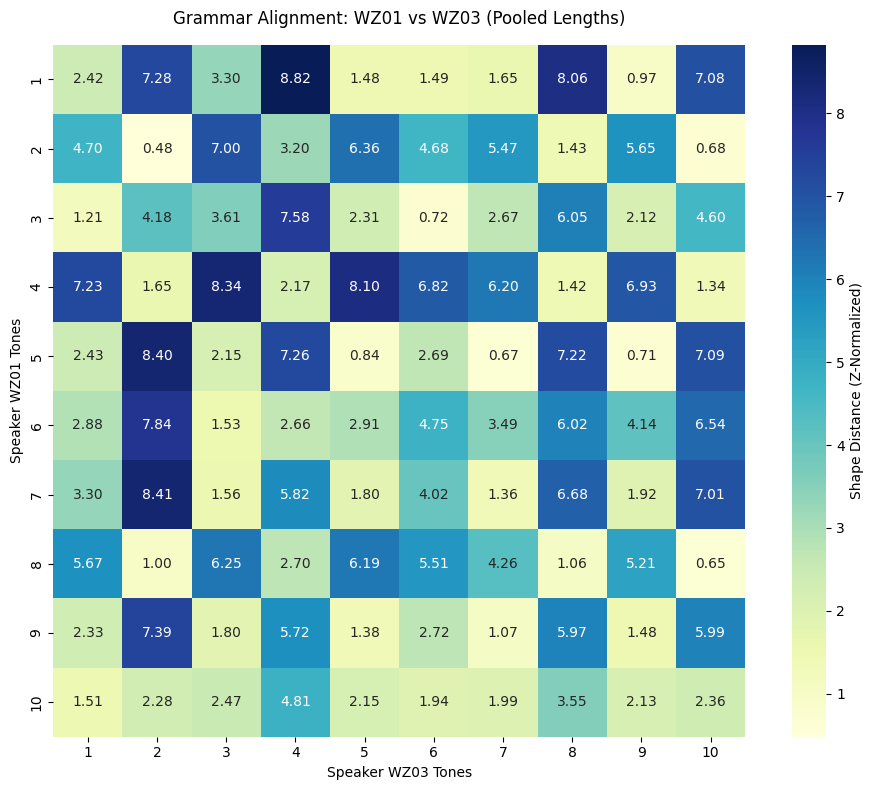

In [53]:
# The above results for WZ (low % of variance explained by tone) are rooted in speaker-specific swaps of tones (we know this from previous investigation)
# Here we explore that by picking two speakers and plotting tonal similarity matrices for them
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dtaidistance import dtw, dtw_barycenter

def get_medoid_index_fast(contours):
    dist_matrix = dtw.distance_matrix(contours, parallel=True, use_c=True)
    full_matrix = dist_matrix + dist_matrix.T
    avg_dists = np.mean(full_matrix, axis=1)
    return np.argmin(avg_dists)

def plot_speaker_to_speaker_grammar(spk_a, spk_b):
    print(f"--- Mapping Tonal Grammar: {spk_a} vs {spk_b} (Pooled Vowel Lengths) ---")
    
    # 1. SAFE Dialect Detection
    spk_a_data = df[df['Speaker'] == spk_a]
    spk_b_data = df[df['Speaker'] == spk_b]
    
    if len(spk_a_data) == 0:
        print(f"Error: Could not find '{spk_a}' in the dataframe.")
        print(f"Available speakers: {sorted(list(set(df['Speaker'].dropna())))}")
        return None
        
    if len(spk_b_data) == 0:
        print(f"Error: Could not find '{spk_b}' in the dataframe.")
        print(f"Available speakers: {sorted(list(set(df['Speaker'].dropna())))}")
        return None
        
    dialect_a = spk_a_data['Dialect'].iloc[0]
    dialect_b = spk_b_data['Dialect'].iloc[0]
    
    # Identify which tones these specific speakers actually produced
    sub_a = df[(df['Speaker'] == spk_a) & (df['DictionaryMatch'] == 'yes')]
    tones_a = sorted([str(t) for t in sub_a['ReclassifiedTone'].unique() if str(t) != 'nan'], 
                     key=lambda x: int(x) if x.isdigit() else 99)
                     
    sub_b = df[(df['Speaker'] == spk_b) & (df['DictionaryMatch'] == 'yes')]
    tones_b = sorted([str(t) for t in sub_b['ReclassifiedTone'].unique() if str(t) != 'nan'], 
                     key=lambda x: int(x) if x.isdigit() else 99)
    
    protos_a = {}
    protos_b = {}
    
    # 2. Harvest Speaker A
    print(f"Harvesting data for {spk_a} ({dialect_a})...")
    for tone in tones_a:
        all_c = []
        all_f = []
        for vl in ['short', 'long']:
            c, f = get_dtw_contours_with_textgrids(dialect_a, tone, target_vl=vl)
            all_c.extend(c)
            all_f.extend(f)
            
        spk_c = [c for c, f in zip(all_c, all_f) if str(f).startswith(spk_a)]
        if len(spk_c) >= 3:
            zc = [(c - np.mean(c)) / (np.std(c) + 1e-8) for c in spk_c]
            m = get_medoid_index_fast(zc)
            protos_a[tone] = dtw_barycenter.dba_loop(zc, c=zc[m], max_it=3)
            
    # 3. Harvest Speaker B
    print(f"Harvesting data for {spk_b} ({dialect_b})...")
    for tone in tones_b:
        all_c = []
        all_f = []
        for vl in ['short', 'long']:
            c, f = get_dtw_contours_with_textgrids(dialect_b, tone, target_vl=vl)
            all_c.extend(c)
            all_f.extend(f)
            
        spk_c = [c for c, f in zip(all_c, all_f) if str(f).startswith(spk_b)]
        if len(spk_c) >= 3:
            zc = [(c - np.mean(c)) / (np.std(c) + 1e-8) for c in spk_c]
            m = get_medoid_index_fast(zc)
            protos_b[tone] = dtw_barycenter.dba_loop(zc, c=zc[m], max_it=3)
            
    # 4. Cross-Compare
    valid_a = sorted(list(protos_a.keys()), key=lambda x: int(x) if x.isdigit() else 99)
    valid_b = sorted(list(protos_b.keys()), key=lambda x: int(x) if x.isdigit() else 99)
    
    if not valid_a or not valid_b:
        print("Not enough data to compare these speakers.")
        return None
        
    print("Calculating alignments...")
    matrix = pd.DataFrame(np.nan, index=valid_a, columns=valid_b)
    
    for t_a in valid_a:
        for t_b in valid_b:
            matrix.loc[t_a, t_b] = dtw.distance(protos_a[t_a], protos_b[t_b])
            
    # 5. Visualize
    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap="YlGnBu", 
                cbar_kws={'label': 'Shape Distance (Z-Normalized)'})
                
    plt.title(f"Grammar Alignment: {spk_a} vs {spk_b} (Pooled Lengths)", pad=15)
    plt.ylabel(f"Speaker {spk_a} Tones")
    plt.xlabel(f"Speaker {spk_b} Tones")
    
    if len(matrix.index) == len(matrix.columns):
        plt.gca().set_aspect('equal')
        
    plt.tight_layout()
    plt.show()
    
    return matrix

# Run it again! If it fails, it will print exactly how your speaker IDs are formatted.
example_matrix = plot_speaker_to_speaker_grammar('WZ01', 'WZ03')

In [30]:
# Plot overall speaker median dispersion by dialect
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dtaidistance import dtw

def plot_overall_speaker_variance_by_dialect(target_dialect):
    print(f"--- Calculating Overall Speaker Volatility for {target_dialect} (Pooled Vowel Lengths) ---")
    
    subset = df[(df['Dialect'] == target_dialect) & 
                (df['Exclude'] == 'Keep') &
                (df['DictionaryMatch'] == 'yes')]
                
    master_speakers = sorted(list(set(subset['Speaker'].dropna())))
    all_tones = sorted([str(t) for t in subset['ReclassifiedTone'].unique() if str(t) != 'nan'], 
                       key=lambda x: int(x) if x.isdigit() else 99)
                       
    dispersion_records = []
    
    for tone in all_tones:
        # Pool lengths during harvest
        all_tone_contours = []
        all_tone_fnames = []
        for vl in ['short', 'long']:
            contours, fnames = get_dtw_contours_with_textgrids(target_dialect, tone, target_vl=vl)
            all_tone_contours.extend(contours)
            all_tone_fnames.extend(fnames)
            
        if len(all_tone_contours) == 0: 
            continue
            
        for spk in master_speakers:
            spk_c = [c for c, f in zip(all_tone_contours, all_tone_fnames) if str(f).startswith(spk)]
            if len(spk_c) < 3: 
                continue
                
            # Z-Normalize and calculate distance to medoid
            zc = [(c - np.mean(c)) / (np.std(c) + 1e-8) for c in spk_c]
            m_idx = get_medoid_index_fast(zc)
            medoid = zc[m_idx]
            
            distances = [dtw.distance(c, medoid) for c in zc]
            median_dispersion = np.median(distances)
            
            dispersion_records.append({
                'Speaker': spk,
                'Tone': tone,
                'Dispersion': median_dispersion
            })
            
    disp_df = pd.DataFrame(dispersion_records)
    
    # Calculate the overall speaker median across all tones
    speaker_overall = disp_df.groupby('Speaker')['Dispersion'].median().reset_index()
    speaker_overall = speaker_overall.sort_values('Dispersion')
    
    # Plotting
    plt.figure(figsize=(10, 6))
    sns.barplot(data=speaker_overall, x='Speaker', y='Dispersion', palette='magma')
    
    global_median = disp_df['Dispersion'].median()
    plt.axhline(global_median, color='red', linestyle='--', label=f'Dialect Median ({global_median:.2f})')
    
    plt.title(f"Overall Speaker Volatility: {target_dialect} (Pooled Vowel Lengths)", pad=15)
    plt.ylabel("Overall Median DTW Distance")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Return the dataframe so you can pass it to the Hypothesis script!
    return disp_df

--- Testing Tonal Crowding vs. Dispersion (WZ, Length-Normalized) ---
Extracting Tone 1 (short vowels) from Tier 2 (N=193)...
✅ Extracted 193 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 1 (long vowels) from Tier 2 (N=464)...
✅ Extracted 464 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (short vowels) from Tier 2 (N=155)...
✅ Extracted 155 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (long vowels) from Tier 2 (N=293)...
✅ Extracted 293 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting T

/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_19308/2380738933.py:92: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(pitch_cents, kernel_size=5)


✅ Extracted 294 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 6, 'parselmouth_error': 0}
Extracting Tone 7 (long vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 8 (short vowels) from Tier 2 (N=279)...


/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_19308/2380738933.py:90: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(interpolated, kernel_size=5)


✅ Extracted 271 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 8, 'parselmouth_error': 0}
Extracting Tone 8 (long vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 9 (short vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 9 (long vowels) from Tier 2 (N=212)...
✅ Extracted 211 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 1, 'parselmouth_error': 0}
Extracting Tone 10 (short vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tie

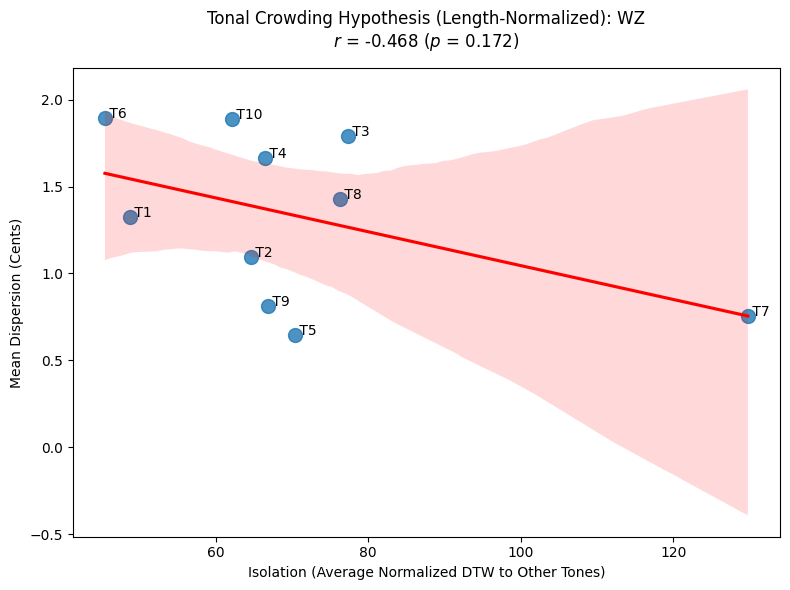

--- Testing Tonal Crowding vs. Dispersion (DZ, Length-Normalized) ---
Extracting Tone 1 (short vowels) from Tier 2 (N=98)...
✅ Extracted 98 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 1 (long vowels) from Tier 2 (N=301)...
✅ Extracted 301 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (short vowels) from Tier 2 (N=137)...
✅ Extracted 137 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (long vowels) from Tier 2 (N=128)...
✅ Extracted 128 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Ton

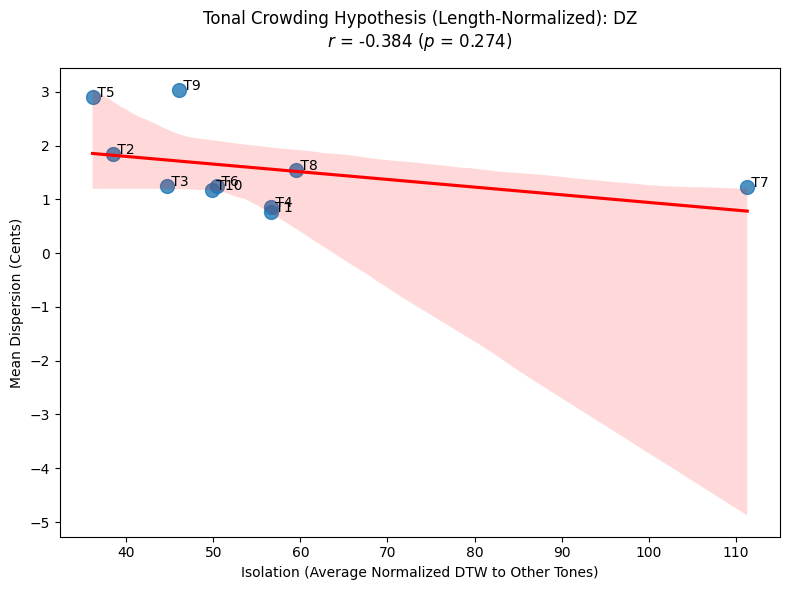

In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from dtaidistance import dtw

def test_crowding_hypothesis_normalized(target_dialect, dispersion_df):
    print(f"--- Testing Tonal Crowding vs. Dispersion ({target_dialect}, Length-Normalized) ---")
    
    # Get the valid tones
    valid_tones = sorted([str(t) for t in dispersion_df['Tone'].unique() if str(t) != 'nan'],
                         key=lambda x: int(x) if x.isdigit() else 99)
    
    # 1. Harvest Medoids for each tone to build the normalized matrix
    medoids = {}
    for tone in valid_tones:
        all_contours = []
        for vl in ['short', 'long']:
            contours, _ = get_dtw_contours_with_textgrids(target_dialect, tone, target_vl=vl)
            all_contours.extend(contours)
        
        if len(all_contours) >= 3:
            m_idx = get_medoid_index_fast(all_contours)
            medoids[tone] = all_contours[m_idx]
            
    # 2. Build the Length-Normalized Inter-Tone Matrix
    isolation_scores = {}
    for t1 in medoids:
        distances = []
        for t2 in medoids:
            if t1 == t2:
                continue
            # Calculate raw DTW distance
            raw_dist = dtw.distance(medoids[t1], medoids[t2])
            
            # THE FIX: Normalize by the average length of the two contours!
            avg_length = (len(medoids[t1]) + len(medoids[t2])) / 2.0
            norm_dist = raw_dist / avg_length
            distances.append(norm_dist)
            
        # Isolation is the mean distance to all *other* tones
        isolation_scores[t1] = np.mean(distances)
        
    isolation_df = pd.Series(isolation_scores, name='Isolation (Normalized)')
    isolation_df.index = isolation_df.index.astype(str)
    
    # 3. Calculate Rigidity (Using MEAN to match the new volatility metrics)
    dispersion_df['Tone'] = dispersion_df['Tone'].astype(str)
    rigidity_scores = dispersion_df.groupby('Tone')['Dispersion'].mean()
    rigidity_scores.name = 'Dispersion (Sloppiness)'
    
    # 4. Align the data safely
    merged = pd.concat([isolation_df, rigidity_scores], axis=1).dropna()
    
    if len(merged) == 0:
        print("Error: Dataframes failed to merge. Check your input variables!")
        return
        
    # 5. Correlate and Plot
    stat, p_val = pearsonr(merged['Isolation (Normalized)'], merged['Dispersion (Sloppiness)'])
    
    plt.figure(figsize=(8, 6))
    sns.regplot(data=merged, x='Isolation (Normalized)', y='Dispersion (Sloppiness)', 
                scatter_kws={'s': 100}, line_kws={'color': 'red'})
    
    for i, row in merged.iterrows():
        plt.annotate(f" T{i}", (row['Isolation (Normalized)'], row['Dispersion (Sloppiness)']))
        
    plt.title(f"Tonal Crowding Hypothesis (Length-Normalized): {target_dialect}\n$r$ = {stat:.3f} ($p$ = {p_val:.3f})", pad=15)
    plt.xlabel("Isolation (Average Normalized DTW to Other Tones)")
    plt.ylabel("Mean Dispersion (Cents)")
    plt.tight_layout()
    plt.show()

# ==========================================
# HOW TO RUN IT FOR BOTH DIALECTS
# ==========================================
# Notice we no longer pass the old inter_tone_matrix in!
test_crowding_hypothesis_normalized('WZ', pure_dispersion_wz)
test_crowding_hypothesis_normalized('DZ', pure_dispersion_dz)

--- Testing Contour Complexity vs. Dispersion (DZ, Polynomial Fit) ---
Extracting Tone 1 (short vowels) from Tier 2 (N=98)...
✅ Extracted 98 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 1 (long vowels) from Tier 2 (N=301)...
✅ Extracted 301 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (short vowels) from Tier 2 (N=137)...
✅ Extracted 137 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (long vowels) from Tier 2 (N=128)...
✅ Extracted 128 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting To

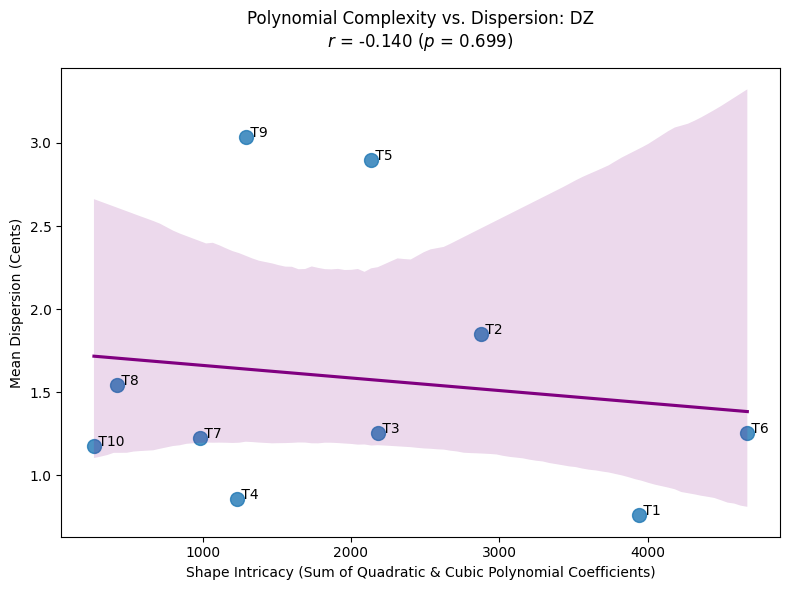

--- Testing Contour Complexity vs. Dispersion (WZ, Polynomial Fit) ---
Extracting Tone 1 (short vowels) from Tier 2 (N=193)...
✅ Extracted 193 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 1 (long vowels) from Tier 2 (N=464)...
✅ Extracted 464 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (short vowels) from Tier 2 (N=155)...
✅ Extracted 155 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (long vowels) from Tier 2 (N=293)...
✅ Extracted 293 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting 

/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_19308/2380738933.py:92: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(pitch_cents, kernel_size=5)


✅ Extracted 294 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 6, 'parselmouth_error': 0}
Extracting Tone 7 (long vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 8 (short vowels) from Tier 2 (N=279)...


/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_19308/2380738933.py:90: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(interpolated, kernel_size=5)


✅ Extracted 271 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 8, 'parselmouth_error': 0}
Extracting Tone 8 (long vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 9 (short vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 9 (long vowels) from Tier 2 (N=212)...
✅ Extracted 211 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 1, 'parselmouth_error': 0}
Extracting Tone 10 (short vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tie

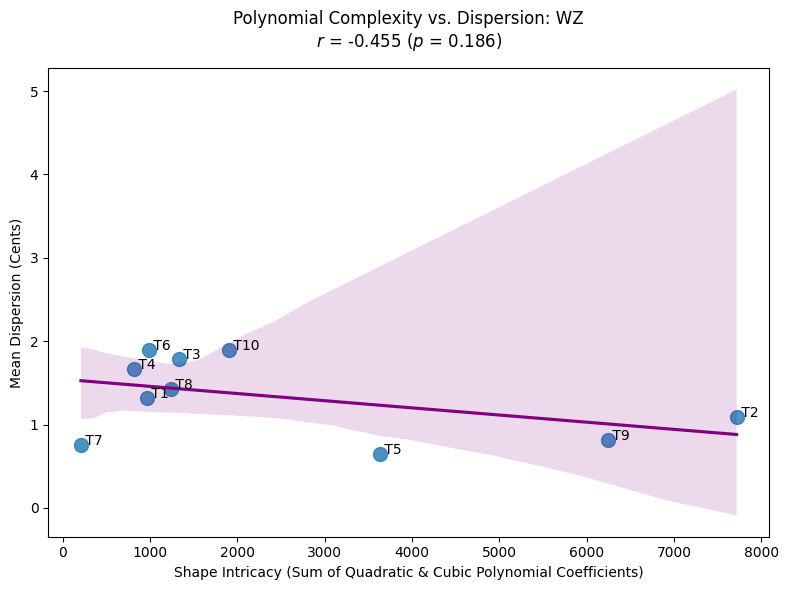

In [59]:
# So if isolation doesn't explain the dispersion (much), does the extent of the pitch contour explain it?
# We might expect (long) level tones to have less dispersion than contour tones.
# We measure complexity by fitting a cubic polynomial to the medoid contour of each tone, and then summing the cubic and quadratic terms.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def test_complexity_hypothesis_poly(target_dialect, dispersion_df):
    print(f"--- Testing Contour Complexity vs. Dispersion ({target_dialect}, Polynomial Fit) ---")
    
    # Get the tones we have dispersion data for
    valid_tones = dispersion_df['Tone'].astype(str).unique()
    
    complexity_scores = {}
    
    for tone in valid_tones:
        # Pool BOTH lengths during harvest!
        all_contours = []
        for vl in ['short', 'long']:
            contours, _ = get_dtw_contours_with_textgrids(target_dialect, tone, target_vl=vl)
            all_contours.extend(contours)
            
        if len(all_contours) < 3:
            continue
            
        # Extract the medoid using raw cents
        m_idx = get_medoid_index_fast(all_contours)
        medoid = all_contours[m_idx]
        
        # Calculate Complexity using Polynomial Fitting
        # 1. Create a normalized time axis from 0 to 1
        x = np.linspace(0, 1, len(medoid))
        
        # 2. Fit a 3rd-degree polynomial curve: Ax^3 + Bx^2 + Cx + D
        # np.polyfit returns coefficients in descending order: [A, B, C, D]
        coefficients = np.polyfit(x, medoid, deg=3)
        
        # 3. Extract the higher-order structural coefficients
        cubic_term = abs(coefficients[0])     # Magnitude of complex S-curves
        quadratic_term = abs(coefficients[1]) # Magnitude of U-shapes / dips / peaks
        
        # 4. Complexity is the combined weight of these non-linear shapes
        structural_complexity = cubic_term + quadratic_term
        complexity_scores[tone] = structural_complexity

    # Align the data
    comp_df = pd.DataFrame.from_dict(complexity_scores, orient='index', columns=['Complexity'])
    comp_df.index.name = 'Tone'
    
    # Merge with dispersion means (updated to mean() to match volatility metrics)
    dispersion_df['Tone'] = dispersion_df['Tone'].astype(str)
    rigidity_scores = dispersion_df.groupby('Tone')['Dispersion'].mean()
    merged = comp_df.join(rigidity_scores).dropna()
    
    if len(merged) == 0:
        print("Error: Failed to merge dataframes.")
        return
        
    # Correlate and Plot
    stat, p_val = pearsonr(merged['Complexity'], merged['Dispersion'])
    
    plt.figure(figsize=(8, 6))
    sns.regplot(data=merged, x='Complexity', y='Dispersion', 
                scatter_kws={'s': 100}, line_kws={'color': 'purple'})
    
    for i, row in merged.iterrows():
        plt.annotate(f" T{i}", (row['Complexity'], row['Dispersion']))
        
    plt.title(f"Polynomial Complexity vs. Dispersion: {target_dialect}\n$r$ = {stat:.3f} ($p$ = {p_val:.3f})", pad=15)
    plt.xlabel("Shape Intricacy (Sum of Quadratic & Cubic Polynomial Coefficients)")
    plt.ylabel("Mean Dispersion (Cents)")
    plt.tight_layout()
    plt.show()

# Run it! 
test_complexity_hypothesis_poly('DZ', pure_dispersion_dz)
test_complexity_hypothesis_poly('WZ', pure_dispersion_wz)

--- Testing Smooth Tone Complexity vs. Dispersion (DZ, Tones 1-6 Only) ---
Extracting Tone 1 (short vowels) from Tier 2 (N=98)...
✅ Extracted 98 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 1 (long vowels) from Tier 2 (N=301)...
✅ Extracted 301 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (short vowels) from Tier 2 (N=137)...
✅ Extracted 137 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (long vowels) from Tier 2 (N=128)...
✅ Extracted 128 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extractin

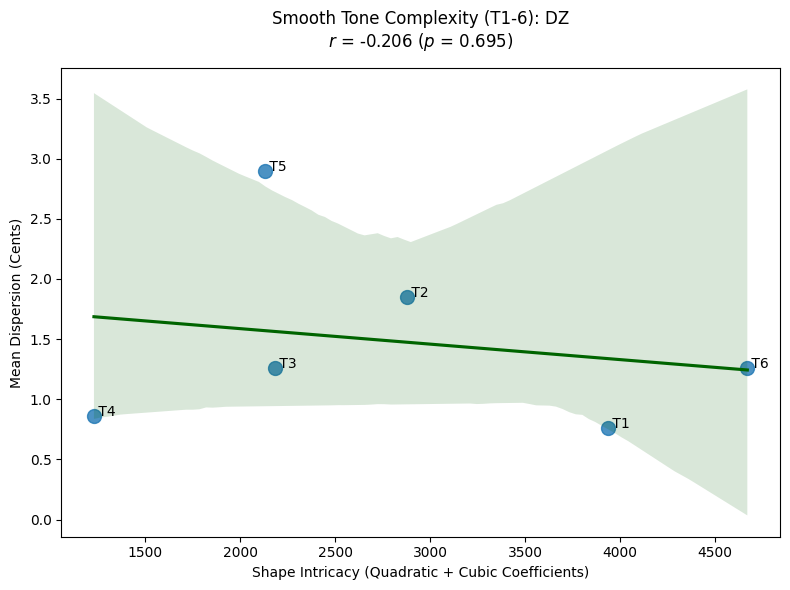

--- Testing Smooth Tone Complexity vs. Dispersion (WZ, Tones 1-6 Only) ---
Extracting Tone 1 (short vowels) from Tier 2 (N=193)...
✅ Extracted 193 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 1 (long vowels) from Tier 2 (N=464)...
✅ Extracted 464 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (short vowels) from Tier 2 (N=155)...
✅ Extracted 155 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (long vowels) from Tier 2 (N=293)...
✅ Extracted 293 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extract

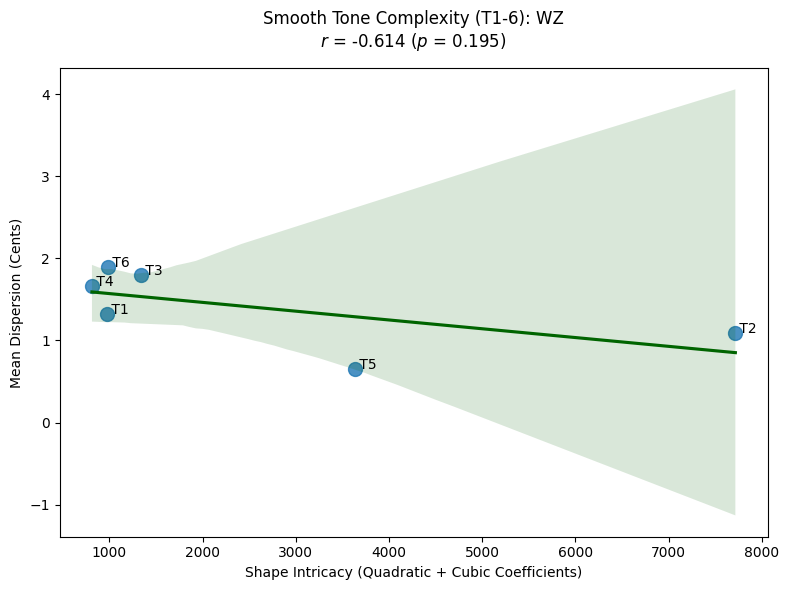

In [ ]:
# Hypothesis: The checked tones 7-10 are polluting the correlation
# because they involve an obstruent closure that adds to the amount of variance (not seen in unchecked tones)
# So if isolation doesn't explain the dispersion (much), does the extent of the pitch contour explain it?
# We might expect (long) level tones to have less dispersion than contour tones.
# We measure complexity by fitting a cubic polynomial to the medoid contour of each tone, and then summing the cubic and quadratic terms.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def test_complexity_hypothesis(target_dialect, dispersion_df):
    print(f"--- Testing Contour Complexity vs. Dispersion ({target_dialect}, Pooled Lengths) ---")
    
    # Get the unchecked tones we have dispersion data for
    smooth_tone_labels = ['1', '2', '3', '4', '5', '6']
    valid_tones = [t for t in dispersion_df['Tone'].astype(str).unique() if t in smooth_tone_labels]
    
    complexity_scores = {}
    
    for tone in valid_tones:
        # Pool BOTH lengths during harvest!
        all_contours = []
        for vl in ['short', 'long']:
            contours, _ = get_dtw_contours_with_textgrids(target_dialect, tone, target_vl=vl)
            all_contours.extend(contours)
            
        if len(all_contours) < 3:
            continue
            
        # NO Z-NORMALIZATION! Use raw cents.
        m_idx = get_medoid_index_fast(all_contours)
        medoid = all_contours[m_idx]
        
        # Calculate Complexity: Average movement in Cents!
        total_movement = np.sum(np.abs(np.diff(medoid)))
        complexity_scores[tone] = total_movement

    # Align the data
    comp_df = pd.DataFrame.from_dict(complexity_scores, orient='index', columns=['Complexity'])
    comp_df.index.name = 'Tone'
    
    # Merge with dispersion medians
    # FORCE string type for safe merging
    dispersion_df['Tone'] = dispersion_df['Tone'].astype(str)
    rigidity_scores = dispersion_df.groupby('Tone')['Dispersion'].median()
    merged = comp_df.join(rigidity_scores).dropna()
    
    if len(merged) == 0:
        print("Error: Failed to merge dataframes.")
        return
        
    # Correlate and Plot
    stat, p_val = pearsonr(merged['Complexity'], merged['Dispersion'])
    
    plt.figure(figsize=(8, 6))
    sns.regplot(data=merged, x='Complexity', y='Dispersion', 
                scatter_kws={'s': 100}, line_kws={'color': 'purple'})
    
    for i, row in merged.iterrows():
        plt.annotate(f" T{i}", (row['Complexity'], row['Dispersion']))
        
    plt.title(f"Contour Complexity Hypothesis: {target_dialect} (Pooled Lengths)\n$r$ = {stat:.3f} ($p$ = {p_val:.3f})", pad=15)
    plt.xlabel("Contour Complexity (Total Pitch Movement)")
    plt.ylabel("Dispersion (Sloppiness)")
    plt.tight_layout()
    plt.show()

# Run it! 
test_complexity_hypothesis('DZ', pure_dispersion_dz)
test_complexity_hypothesis('WZ', pure_dispersion_wz)

--- Generating Tonal Family Tree (Dendrogram) for DZ ---


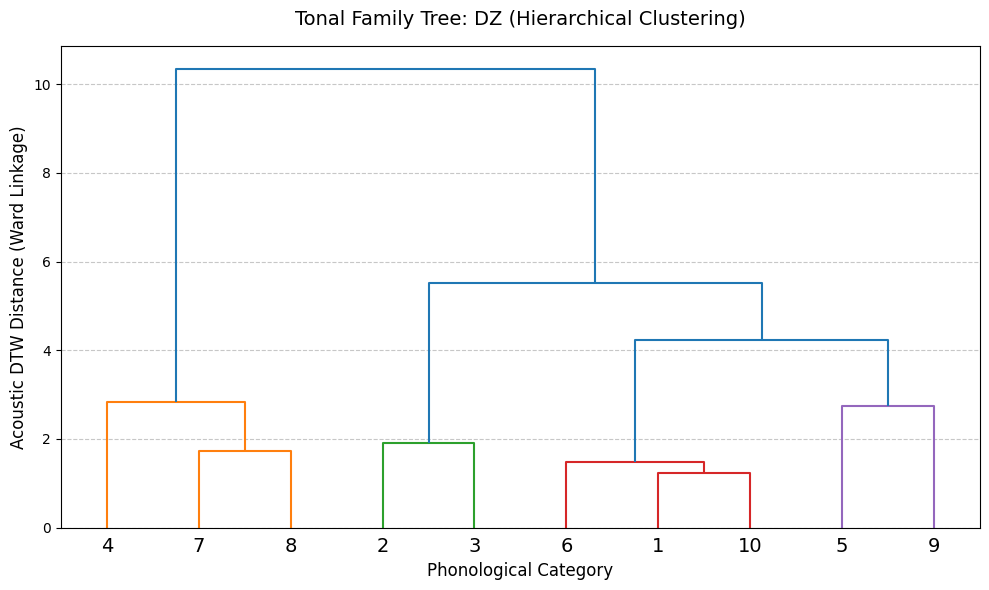

--- Generating Tonal Family Tree (Dendrogram) for WZ ---


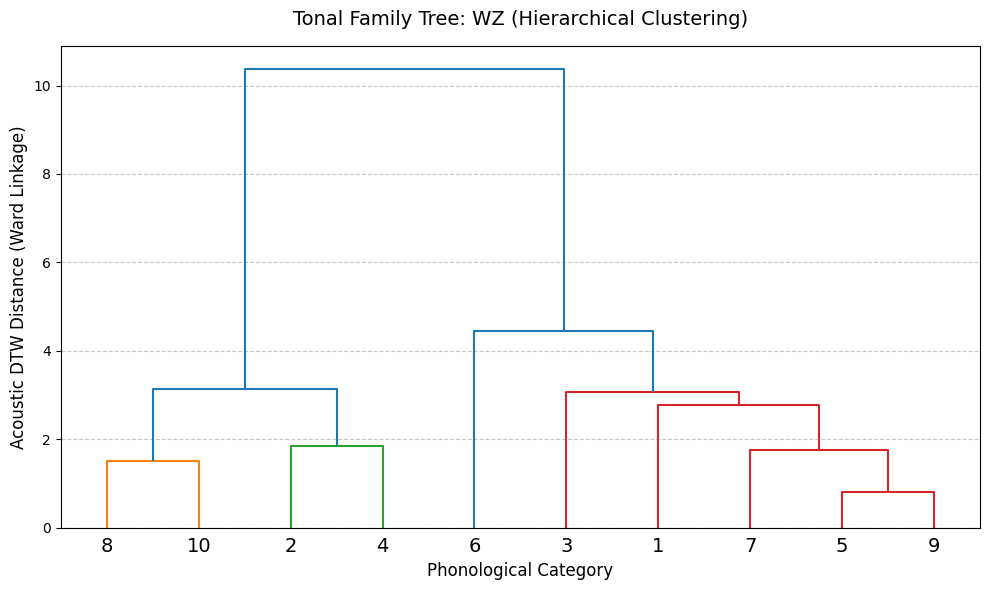

In [71]:
# Hierarchical Clustering of tones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

def plot_tonal_family_tree(target_dialect, inter_tone_matrix):
    print(f"--- Generating Tonal Family Tree (Dendrogram) for {target_dialect} ---")
    
    # 1. Clean the matrix
    # The clustering algorithm requires a perfectly symmetric matrix with 0.0s on the diagonal
    matrix = inter_tone_matrix.fillna(0)
    
    # Ensure perfect symmetry (sometimes floating point math leaves a tiny difference)
    sym_matrix = (matrix + matrix.T) / 2
    np.fill_diagonal(sym_matrix.values, 0)
    
    # 2. Convert to a condensed distance array (required by SciPy)
    condensed_dist = squareform(sym_matrix)
    
    # 3. Perform Hierarchical/Agglomerative Clustering
    # 'ward' linkage minimizes the variance of clusters being merged
    Z = hierarchy.linkage(condensed_dist, method='ward')
    
    # 4. Plot the Dendrogram
    plt.figure(figsize=(10, 6))
    
    # Color threshold sets where the tree changes color to highlight distinct families
    hierarchy.dendrogram(Z, labels=matrix.index.astype(str).tolist(), 
                         leaf_rotation=0, leaf_font_size=14, 
                         color_threshold=np.percentile(Z[:, 2], 70))
    
    plt.title(f"Tonal Family Tree: {target_dialect} (Hierarchical Clustering)", pad=15, fontsize=14)
    plt.ylabel("Acoustic DTW Distance (Ward Linkage)", fontsize=12)
    plt.xlabel("Phonological Category", fontsize=12)
    
    # Add a subtle grid for easier distance reading
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Run it for both dialects!
plot_tonal_family_tree('DZ', pure_tone_matrix_dz)
plot_tonal_family_tree('WZ', pure_tone_matrix_wz)

In [ ]:
# K-nearest Neighbours using our calculated medoid prototypes for each tone (takes a long time - didn't confirm that it works properly)
import pandas as pd
import numpy as np
from dtaidistance import dtw
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def run_knn_mismatch_classifier(target_dialect, k=1):
    print(f"--- Running Nearest-Prototype Classifier for {target_dialect} Mismatches ---")
    
    # 1. Split the data
    train_data = df[(df['Dialect'] == target_dialect) & 
                    (df['Exclude'] == 'Keep') & 
                    (df['DictionaryMatch'] == 'yes')]
                    
    test_data = df[(df['Dialect'] == target_dialect) & 
                   (df['Exclude'] == 'Keep') & 
                   (df['DictionaryMatch'] == 'no')]
                   
    if len(test_data) == 0:
        print(f"No mismatched tokens found for {target_dialect} to classify!")
        return
        
    print(f"Found {len(test_data)} mismatched tokens to classify.")
    
    # 2. Build the Prototypes (Medoids) from the Training Data
    tones = sorted([str(t) for t in train_data['ReclassifiedTone'].unique() if str(t) != 'nan'], 
                   key=lambda x: int(x) if x.isdigit() else 99)
    prototypes = {}
    
    print("Building grammatical prototypes...")
    for tone in tones:
        all_c = []
        for vl in ['short', 'long']:
            c, _ = get_dtw_contours_with_textgrids(target_dialect, tone, target_vl=vl)
            all_c.extend(c)
        if len(all_c) >= 3:
            zc = [(c - np.mean(c)) / (np.std(c) + 1e-8) for c in all_c]
            m_idx = get_medoid_index_fast(zc)
            prototypes[tone] = zc[m_idx]
            
    # 3. Classify the Mismatched Tokens
    predictions = []
    actual_annotations = []
    filenames = []
    
    print("Classifying mismatched tokens...")
    # We iterate through what the speaker ACTUALLY produced (your human annotation)
    # assuming your annotation is stored in 'ReclassifiedTone' for the 'no' tokens too.
    for idx, row in test_data.iterrows():
        human_label = str(row.get('ReclassifiedTone', 'Unknown'))
        fname = row['Filename']
        
        # We need to fetch the single contour for this mismatched file.
        # This uses your existing extraction logic.
        try:
            # Assuming you have a way to fetch a single contour by filename, or we extract it:
            # For simplicity in this script, we'll harvest it exactly like the others.
            contour, f_list = get_dtw_contours_with_textgrids(target_dialect, human_label, target_vl=row['VowelLength'])
            
            # Find the specific file in the harvested list
            match_idx = [i for i, f in enumerate(f_list) if fname in str(f)]
            if not match_idx:
                continue
                
            raw_c = contour[match_idx[0]]
            z_c = (raw_c - np.mean(raw_c)) / (np.std(raw_c) + 1e-8)
            
            # Compare to all prototypes
            distances = {}
            for t_label, proto in prototypes.items():
                distances[t_label] = dtw.distance(z_c, proto)
                
            # The prediction is the tone with the absolute smallest DTW distance
            predicted_tone = min(distances, key=distances.get)
            
            predictions.append(predicted_tone)
            actual_annotations.append(human_label)
            filenames.append(fname)
            
        except Exception as e:
            continue
            
    if len(predictions) == 0:
        print("Could not extract contours for the test set.")
        return
        
    # 4. Evaluate the Results
    results_df = pd.DataFrame({
        'Filename': filenames,
        'Human_Annotation': actual_annotations,
        'Machine_Prediction': predictions
    })
    
    # Calculate Accuracy
    correct = sum(results_df['Human_Annotation'] == results_df['Machine_Prediction'])
    accuracy = correct / len(results_df)
    print(f"\n--- Classification Results ---")
    print(f"Total Mismatches Evaluated: {len(results_df)}")
    print(f"Machine-Human Agreement: {accuracy:.1%} ({correct}/{len(results_df)})")
    
    # Plot a Confusion Matrix so you can see EXACTLY where you and the machine disagreed
    labels = sorted(list(set(actual_annotations + predictions)), key=lambda x: int(x) if x.isdigit() else 99)
    cm = confusion_matrix(actual_annotations, predictions, labels=labels)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f"Machine vs. Human Annotation of Mismatches ({target_dialect})", pad=15)
    plt.ylabel('Your Human Annotation (ReclassifiedTone)')
    plt.xlabel('Machine Prediction (Nearest Prototype)')
    plt.show()
    
    return results_df

# Run the classifier!
mismatch_results_wz = run_knn_mismatch_classifier('WZ')
mismatch_results_dz = run_knn_mismatch_classifier('DZ')

--- Running Nearest-Prototype Classifier for WZ Mismatches ---
Found 1819 mismatched tokens to classify.
Building grammatical prototypes...
Extracting Tone 1 (short vowels) from Tier 2 (N=193)...
✅ Extracted 193 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 1 (long vowels) from Tier 2 (N=464)...


KeyboardInterrupt: 

In [ ]:
# The above KNN has a few disadvantages:
# 1. It's very slow
# 2. It doesn't take into account duration, which is the most important feature for distinguishing checked vs. unchecked tones (7-10 vs. 1-6)
# 3. It crashed because of NaN values for some tokens' Vowel Lengths (I think...)
# So we try an SVM version that uses the distance from each tone's medoid plus the duration of the token as features.
# This isn't working properly yet and requires serious fixing
import pandas as pd
import numpy as np
from dtaidistance import dtw
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def run_11D_svm_classifier(target_dialect):
    print(f"--- Training 11-Dimensional SVM for {target_dialect} ---")
    
    # 1. Grab our valid grammatical tones
    train_data = df[(df['Dialect'] == target_dialect) & 
                    (df['Exclude'] == 'Keep') & 
                    (df['DictionaryMatch'] == 'yes')]
    
    tones = sorted([str(t) for t in train_data['ReclassifiedTone'].unique() if str(t) != 'nan'], 
                   key=lambda x: int(x) if x.isdigit() else 99)
                   
    # 2. Harvest all contours ONCE to save massive amounts of time
    print("Harvesting all contours (this takes a moment, but only happens once!)...")
    all_training_contours = {}
    prototypes = {}
    
    for tone in tones:
        all_c = []
        for vl in ['short', 'long']:
            c, _ = get_dtw_contours_with_textgrids(target_dialect, tone, target_vl=vl)
            all_c.extend(c)
            
        all_training_contours[tone] = all_c
        
        # Build the Medoid for this tone
        if len(all_c) >= 3:
            zc = [(c - np.mean(c)) / (np.std(c) + 1e-8) for c in all_c]
            m_idx = get_medoid_index_fast(zc)
            prototypes[tone] = zc[m_idx]

    # 3. Build the 11D Training Vectors
    print("Building SVM Training Vectors...")
    X_train = []
    y_train = []
    
    for tone_label, contours in all_training_contours.items():
        for raw_c in contours:
            z_c = (raw_c - np.mean(raw_c)) / (np.std(raw_c) + 1e-8)
            
            # Features 1-10: Distance to each grammatical prototype
            features = []
            for t_proto in tones:
                dist = dtw.distance(z_c, prototypes[t_proto])
                features.append(dist)
                
            # Feature 11: Absolute Duration (using length of contour array as proxy)
            features.append(len(raw_c))
            
            X_train.append(features)
            y_train.append(tone_label)
            
    # Train the SVM! (This takes literally 0.1 seconds)
    print("Training the Support Vector Machine...")
    svm_model = SVC(kernel='rbf', class_weight='balanced')
    svm_model.fit(X_train, y_train)
    
    print("SVM Trained successfully! Ready to classify mismatches.")
    return svm_model, prototypes, tones

# Run the setup!
dz_svm, dz_protos, dz_tones = run_11D_svm_classifier('DZ')
wz_svm, wz_protos, wz_tones = run_11D_svm_classifier('WZ')

--- Training 11-Dimensional SVM for DZ ---
Harvesting all contours (this takes a moment, but only happens once!)...
Extracting Tone 1 (short vowels) from Tier 2 (N=98)...
✅ Extracted 98 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 1 (long vowels) from Tier 2 (N=301)...
✅ Extracted 301 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (short vowels) from Tier 2 (N=137)...
✅ Extracted 137 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (long vowels) from Tier 2 (N=128)...
✅ Extracted 128 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_sho

/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_39050/2380738933.py:92: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(pitch_cents, kernel_size=5)


✅ Extracted 294 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 6, 'parselmouth_error': 0}
Extracting Tone 7 (long vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 8 (short vowels) from Tier 2 (N=279)...


/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_39050/2380738933.py:90: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(interpolated, kernel_size=5)


✅ Extracted 271 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 8, 'parselmouth_error': 0}
Extracting Tone 8 (long vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 9 (short vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 9 (long vowels) from Tier 2 (N=212)...
✅ Extracted 211 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 1, 'parselmouth_error': 0}
Extracting Tone 10 (short vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tie

In [80]:
import os

def evaluate_mismatches_fast(target_dialect, trained_svm, prototypes, tones_list):
    print(f"--- Fast Evaluating Mismatched Tokens for {target_dialect} ---")
    
    test_data = df[(df['Dialect'] == target_dialect) & 
                   (df['Exclude'] == 'Keep') & 
                   (df['DictionaryMatch'] == 'no')]
                   
    print(f"Found {len(test_data)} mismatched tokens. Building cache...")
    
    contour_cache = {}
    unique_human_labels = [str(t) for t in test_data['ReclassifiedTone'].unique() if str(t) != 'nan']
    
    for label in unique_human_labels:
        for vl in ['short', 'long']:
            try:
                c_list, f_list = get_dtw_contours_with_textgrids(target_dialect, label, target_vl=vl)
                for contour, full_path in zip(c_list, f_list):
                    # Strip everything to get just the base filename (e.g., 'DZ01_T1_S1')
                    base_name = os.path.splitext(os.path.basename(str(full_path)))[0]
                    contour_cache[base_name] = contour
            except:
                pass
            
    print(f"Cache built with {len(contour_cache)} unique files. Classifying...")
    
    X_test, y_human = [], []
    
    for idx, row in test_data.iterrows():
        human_label = str(row.get('ReclassifiedTone', 'Unknown'))
        # Strip the extension from the DF filename too
        raw_df_name = str(row['Filename'])
        df_base_name = os.path.splitext(os.path.basename(raw_df_name))[0]
        
        # Look for the match
        if df_base_name in contour_cache:
            raw_c = contour_cache[df_base_name]
            z_c = (raw_c - np.mean(raw_c)) / (np.std(raw_c) + 1e-8)
            
            features = []
            for t_proto in tones_list:
                dist = dtw.distance(z_c, prototypes[t_proto])
                features.append(dist)
            features.append(len(raw_c)) # Duration feature
            
            X_test.append(features)
            y_human.append(human_label)
            
    if not X_test:
        # Debugging output to see what went wrong
        sample_df = os.path.splitext(os.path.basename(str(test_data['Filename'].iloc[0])))[0] if not test_data.empty else "N/A"
        sample_cache = list(contour_cache.keys())[0] if contour_cache else "EMPTY"
        print(f"DEBUG: DF name sample: '{sample_df}'")
        print(f"DEBUG: Cache name sample: '{sample_cache}'")
        print(f"Error: No mismatched tokens successfully matched in the cache for {target_dialect}.")
        return

    # Predictions
    predictions = trained_svm.predict(X_test)
    y_human_arr = np.array(y_human)
    accuracy = accuracy_score(y_human_arr, predictions)
    
    print(f"\n--- 11D SVM Results ({target_dialect}) ---")
    print(f"Agreement: {accuracy:.1%} ({sum(y_human_arr == predictions)}/{len(y_human_arr)})")
    
    labels = sorted(list(set(y_human + list(predictions))), key=lambda x: int(x) if x.isdigit() else 99)
    cm = confusion_matrix(y_human_arr, predictions, labels=labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=labels, yticklabels=labels)
    plt.title(f"SVM (Shape + Duration) vs. Human Mismatches ({target_dialect})")
    plt.ylabel('Human Annotation')
    plt.xlabel('Machine Prediction')
    plt.show()

# Run it!
evaluate_mismatches_fast('DZ', dz_svm, dz_protos, dz_tones)
evaluate_mismatches_fast('WZ', wz_svm, wz_protos, wz_tones)

--- Fast Evaluating Mismatched Tokens for DZ ---
Found 1976 mismatched tokens. Building cache...
Extracting Tone 2 (short vowels) from Tier 2 (N=137)...
✅ Extracted 137 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (long vowels) from Tier 2 (N=128)...
✅ Extracted 128 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 5 (short vowels) from Tier 2 (N=35)...
✅ Extracted 35 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 5 (long vowels) from Tier 2 (N=216)...
✅ Extracted 216 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmout

/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_39050/2380738933.py:92: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(pitch_cents, kernel_size=5)


✅ Extracted 294 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 6, 'parselmouth_error': 0}
Extracting Tone 7 (long vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 10 (short vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 10 (long vowels) from Tier 2 (N=178)...
✅ Extracted 178 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 5 (short vowels) from Tier 2 (N=79)...
✅ Extracted 79 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, '

/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_39050/2380738933.py:90: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(interpolated, kernel_size=5)


✅ Extracted 271 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 8, 'parselmouth_error': 0}
Extracting Tone 8 (long vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 4 (short vowels) from Tier 2 (N=29)...
✅ Extracted 29 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 4 (long vowels) from Tier 2 (N=154)...
✅ Extracted 154 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Cache built with 3867 unique files. Classifying...
DEBUG: DF name sample: 'WZ03_9_179_1'
DEBUG: Cache name sample: 'WZ03_7_147_1'
Error: No mism

In [81]:
print(f"DF Sample: '{df[df['DictionaryMatch'] == 'no']['Filename'].iloc[0]}'")
# Run this only if you still have that 'f_list' from the last run
try: print(f"Cache Sample: '{f_list[0]}'")
except: print("f_list not found.")

DF Sample: 'WZ03_9_179_1'
f_list not found.
